In [1]:
import sys
import importlib
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

sys.path.append("/Users/arthurbenard/Project 1B/src")

In [2]:
import shap
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import catboost
from catboost import CatBoostClassifier

my_model = joblib.load('final_xgb_model.joblib')

In [3]:
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

In [4]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GroupShuffleSplit, learning_curve, GroupKFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score
from sklearn.feature_selection import SelectKBest, chi2, f_classif
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample

In [5]:
from data_converter.hplc_data_handler import cleaning_array_by_cas, NMR_SOLVENTS, smiles_to_fingerprint, scrub, compress_fingerprints_pca, calculate_descriptors, extract_solvent_physics, calculate_mlwt
from controller.predictor_runner import generate_ml_ready_file_fingerprint_solvent, generate_ml_ready_file_onehot_solvent, generate_ml_file_with_logs, solubility_file_matrix, add_logs_to_df, add_matrix_id_to_df, run_descriptor_competition, run_hyperparameter_competition, unknown_column_machine_test, strict_unknown_column_machine_test
from analysis.analysis import run_ablation_study, plot_comparison, run_data_fraction, plot_learning_curve, run_ablation_xgboost, learning_curve_trainsize_kselectors, run_matrix_ablation, accuracy_per_matrix, rt_bin_analysis, mw_bin_analysis, solvent_bin_analysis

In [6]:
def plot_shap_mw_rt_correlation(loaded_model, df, phys_feature_list):
    print("Calculating SHAP values to map the MW/RT interaction\n")
    
    # To explain the AI, we have to feed it data in the exact format it was trained on.
    X_rt = df[['RT']].values 
    X_phys = df[phys_feature_list].values 
    X_mat = np.vstack(df['Matrix_Packed_Array'].values)
    X_final = np.hstack((X_rt, X_phys, X_mat))
    # Create a clean list of names for every single column so the plot has readable labels.
    matrix_names = [f"Matrix_{i+1}" for i in range(10)]
    feature_names = ['RT'] + phys_feature_list + matrix_names
    
    # Unlike standard correlation, TreeExplainer physically reads the XGBoost 
    # decision trees. It uses game theory to calculate exactly how much "credit" each 
    # feature gets for pushing the final prediction toward Soluble (1) or Insoluble (0).
    explainer = shap.TreeExplainer(loaded_model)
    # This returns a matrix identical in size to X_final. Instead of raw physical values
    # it contains the AI's internal impact scores (like "Weight of 200 Da added +0.15 to the solubility probability").
    shap_values = explainer.shap_values(X_final)
    


    
    # Create a nice wide canvas
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # This is the core function that proves interaction between two features.
    shap.dependence_plot(
        "MolWt",                 # Feature for the X-axis
        shap_values,             # The AI's calculated impact scores
        X_final,                 # The raw data
        feature_names=feature_names,
        interaction_index="RT",  # Feature to use for the Color Map
        show=False,              # Wait to show so we can tweak titles
        ax=ax
    )
    
    # Add a custom title
    ax.set_title('AI Learned Interaction: Molecular Weight vs. Retention Time', 
                 fontsize=14, fontweight='bold', pad=20)
    
    # Tweak the layout to prevent cut-off labels
    plt.tight_layout()
    plt.show()

In [6]:
# Creating the new dataframe, the first steps can be kept
raw_df = pd.read_excel('/Users/arthurbenard/Project 1B/data/Fichier final (RT+sol)_with_smiles.xlsx')
raw_df['SMILES'] = raw_df['solute_smiles'].astype(str).str.strip()

sol_matrix_dirty= pd.read_excel('/Users/arthurbenard/Project 1B/data/Master_Solubility_Matrix.xlsx')
sol_matrix_dirty['SMILES'] = sol_matrix_dirty['solute_smiles'].astype(str).str.strip()

sol_matrix = sol_matrix_dirty.drop_duplicates(subset=['SMILES'], keep='first')

# Deleting rows with signals = 0
raw_df = raw_df[raw_df['RT'] != 0].copy()

# Merges the predicted solubilities with the future df like before
all_dfs_final = []

for sol_name in NMR_SOLVENTS.keys():
    target_col = f"predicted_logS_{sol_name}"
    
    if target_col in sol_matrix.columns:
        temp_raw = raw_df[['SMILES', 'RT', 'Matrix ID Name']].copy()
        temp_sol = sol_matrix[['SMILES', target_col]].copy()
        temp = temp_raw.merge(temp_sol, on='SMILES', how='inner')
        
        if len(temp) > 0:
            temp = temp.rename(columns={target_col: 'logS'})
            temp['Solvent_Name'] = sol_name
            temp['Soluble'] = (temp['logS'] >= -2).astype(int)
            all_dfs_final.append(temp)
            print(f" Added {sol_name}: {len(temp)} rows")
        else:
            print(f" {sol_name}: Merge resulted in 0 rows.")
    else:
        print(f" {target_col} not found in sol_matrix columns.")


# Combines everything
df_desc = pd.concat(all_dfs_final, ignore_index=True)


 Added MeOH: 895 rows
 Added ACN: 895 rows
 Added DMSO: 895 rows
 Added DCM: 895 rows
 Added CHCl3: 895 rows


In [7]:
# Removes 'matrix ID ' in the original column names (was a problem)
df_desc['Matrix ID Name'] = df_desc['Matrix ID Name'].str.replace('matrix ID ', '', regex=False).str.strip()

# The first step is to rename the columns in the given file
matrix_vectors_df = pd.read_excel('/Users/arthurbenard/Project 1B/data/matrixIDs.xlsx')
matrix_vectors_df = matrix_vectors_df.rename(columns={'MatrixID': 'Matrix ID Name'})

# Looks at all the column headers in the file. If the header starts with the letter 'M', adds it to my list.  That way, if new components are 
# given the code adapts easily.
m_cols = [col for col in matrix_vectors_df.columns if col.startswith('M') and col != 'Matrix ID Name']

# Creating a dictionnary, .iterrows() function tells Python to read file line by line and creates key/value pair by grabbing numbers inside m_cols 
# then converting them to decimals then wrapping them in a single array.
matrix_vector_dict = {
    row['Matrix ID Name']: row[m_cols].values.astype(float)
    for _, row in matrix_vectors_df.iterrows()
}

# .map() instantly looks at 'Matrix ID Name' for all rows and attributes the specific array
df_desc['Matrix_Packed_Array'] = df_desc['Matrix ID Name'].map(matrix_vector_dict)


In [8]:
print("1/3 Mapping Solvent Physics...")
unique_solvents = pd.DataFrame({'Solvent_Name': df_desc['Solvent_Name'].unique()})
unique_solvents[['Sol_Dielectric', 'Sol_Hansen_D', 'Sol_Hansen_P', 'Sol_Hansen_H']] = unique_solvents['Solvent_Name'].apply(extract_solvent_physics).apply(pd.Series)
df_desc = df_desc.merge(unique_solvents, on='Solvent_Name', how='left')

1/3 Mapping Solvent Physics...


In [11]:
print("2/3 Mapping SMILES Descriptors...")
unique_smiles = pd.DataFrame({'SMILES': df_desc['SMILES'].unique()})
unique_smiles[['MolLogP', 'TPSA', 'MolWt', 'NumHDonors', 'NumHAcceptors']] = unique_smiles['SMILES'].apply(calculate_descriptors).apply(pd.Series)
df_desc = df_desc.merge(unique_smiles, on='SMILES', how='left')

2/3 Mapping SMILES Descriptors...


In [9]:
print("2/3.5 Mapping SMILES Descriptors...")
unique_smiles_other =pd.DataFrame({'SMILES': df_desc['SMILES'].unique()})
unique_smiles_other[['MolWt', 'NumHDonors', 'NumHAcceptors']] = unique_smiles_other['SMILES'].apply(calculate_mlwt).apply(pd.Series)
df_desc = df_desc.merge(unique_smiles_other, on='SMILES', how='left')

2/3.5 Mapping SMILES Descriptors...


In [ ]:
print("3/3 Generating Structural Fingerprints...")
fp_dict = {smi: smiles_to_fingerprint(smi) for smi in df_desc['SMILES'].unique()}
df_desc['Sample Fingerprint'] = df_desc['SMILES'].map(fp_dict)

print(f"\n DATASET GENERATED SUCCESSFULLY")

Calculating SHAP values to map the MW/RT interaction

Generating SHAP Dependence Plot


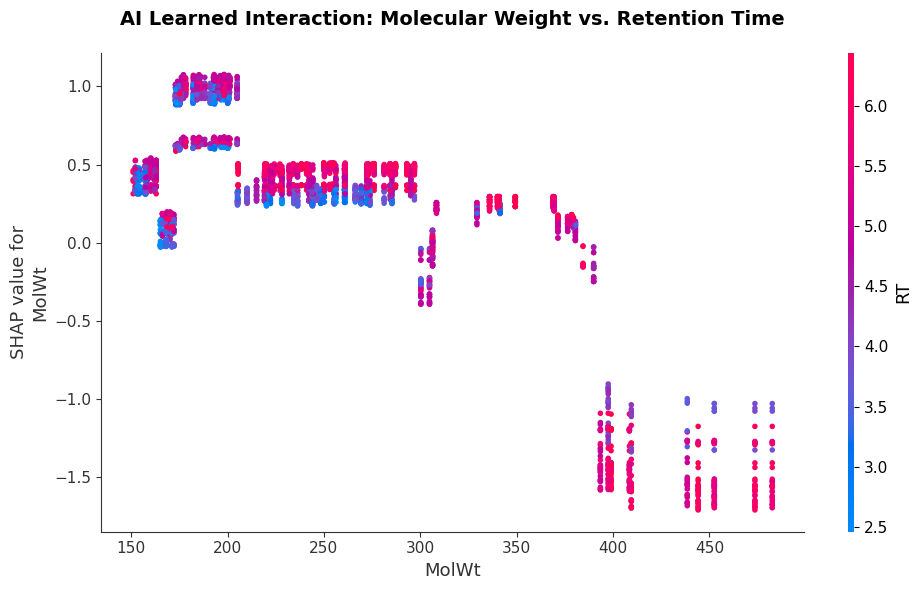

In [16]:
my_features = ['MolWt', 'Sol_Dielectric', 'Sol_Hansen_D', 'Sol_Hansen_P', 'Sol_Hansen_H']
plot_shap_mw_rt_correlation(my_model, df_desc, my_features)

In [11]:
def plot_shap_rt_correlation(loaded_model, df, phys_feature_list):
    
    # To explain the AI, we have to feed it data in the exact format it was trained on.
    X_rt = df[['RT']].values 
    X_phys = df[phys_feature_list].values 
    X_mat = np.vstack(df['Matrix_Packed_Array'].values)
    X_final = np.hstack((X_rt, X_phys, X_mat))
    # Create a clean list of names for every single column so the plot has readable labels.
    matrix_names = [f"Matrix_{i+1}" for i in range(10)]
    feature_names = ['RT'] + phys_feature_list + matrix_names
    
    # Unlike standard correlation, TreeExplainer physically reads the XGBoost 
    # decision trees. It uses game theory to calculate exactly how much "credit" each 
    # feature gets for pushing the final prediction toward Soluble (1) or Insoluble (0).
    explainer = shap.TreeExplainer(loaded_model)
    # This returns a matrix identical in size to X_final. Instead of raw physical values
    # it contains the AI's internal impact scores (like "Weight of 200 Da added +0.15 to the solubility probability").
    shap_values = explainer.shap_values(X_final)
    


    
    # Create a nice wide canvas
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # This is the core function that proves interaction between two features.
    shap.dependence_plot(
        "RT",                 # Feature for the X-axis
        shap_values,             # The AI's calculated impact scores
        X_final,                 # The raw data
        feature_names=feature_names,
        interaction_index=None,  # Feature to use for the Color Map
        show=False,              # Wait to show so we can tweak titles
        ax=ax
    )
    
    # Add a custom title
    ax.set_title('SHAP values for Retention Time', 
                 fontsize=14, fontweight='bold', pad=20)
    
    # Tweak the layout to prevent cut-off labels
    plt.tight_layout()
    plt.show()

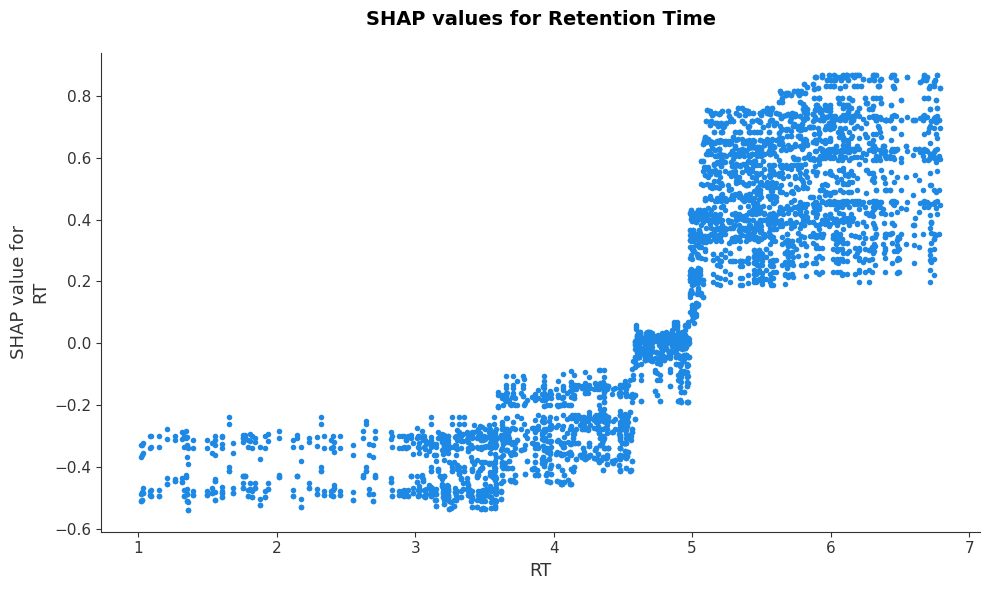

In [25]:
my_features = ['MolWt', 'Sol_Dielectric', 'Sol_Hansen_D', 'Sol_Hansen_P', 'Sol_Hansen_H']
plot_shap_rt_correlation(my_model, df_desc, my_features)

In [40]:
def plot_custom_shap_categorical(loaded_model, df, phys_feature_list, base_feature, color_col):
    
    X_rt = df[['RT']].values 
    X_phys = df[phys_feature_list].values 
    X_mat = np.vstack(df['Matrix_Packed_Array'].values)
    X_final = np.hstack((X_rt, X_phys, X_mat))
    
    feature_names = ['RT'] + phys_feature_list + [f"Matrix_{i+1}" for i in range(10)]
    
    # --- 2. CALCULATE SHAP VALUES ---
    explainer = shap.TreeExplainer(loaded_model)
    shap_values = explainer.shap_values(X_final)
    
    # --- 3. ISOLATE THE SPECIFIC MATH WE NEED ---
    # Find exactly which column number belongs to our base_feature (e.g., 'MolWt')
    feature_idx = feature_names.index(base_feature)
    
    # Extract only the SHAP values and raw data for that specific feature
    specific_shap_values = shap_values[:, feature_idx]
    specific_feature_data = X_final[:, feature_idx]
    
    # --- 4. THE TRICK: STITCH IT BACK TO THE TEXT DATA ---
    
    plot_df = pd.DataFrame({
        'Raw_Value': specific_feature_data,
        'SHAP_Value': specific_shap_values,
        'Color_Label': df[color_col].values  # Pulling the text directly from the original dataframe!
    })
    
    # --- 5. BUILD THE BEAUTIFUL PLOT ---
    plt.figure(figsize=(11, 6))
    sns.set_theme(style="whitegrid")
    
    # We use seaborn because it handles categorical colors effortlessly
    sns.scatterplot(
        data=plot_df,
        x='Raw_Value',
        y='SHAP_Value',
        hue='Color_Label',
        palette='tab10', # A distinct color palette perfect for different machine/solvent names
        alpha=0.7,
        s=60,
        edgecolor='black',
        linewidth=0.5
    )
    
    # Draw the baseline 0 line
    plt.axhline(0, color='gray', linestyle='--', linewidth=1.5, alpha=0.8)
    
    # Add titles and labels
    plt.title(f'AI Decision Matrix', fontsize=15, fontweight='bold', pad=15)
    plt.xlabel(f'{base_feature} (Raw Value)', fontsize=12, fontweight='bold')
    plt.ylabel(f'SHAP Value (Impact on Solubility)', fontsize=12, fontweight='bold')
    
    # Move the legend entirely OUTSIDE the plot so it doesn't block the data dots
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title=color_col, borderaxespad=0)
    
    plt.tight_layout()
    plt.show()

In [36]:
def evaluate_by_solvent(df, phys_feature_list,scale_weight, solvent_col='Solvent_Name'):
    
    splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
    
    # Get the row indices for the training and testing sets
    train_idx, test_idx = next(splitter.split(df, groups=df['SMILES']))
    
    # Create the actual DataFrames
    df_train = df.iloc[train_idx].copy()
    df_test = df.iloc[test_idx].copy()
    
    
    # --- 2. REBUILD FEATURE MATRICES FOR BOTH SETS ---
    def build_matrix(data):
        X_rt = data[['RT']].values 
        X_phys = data[phys_feature_list].values 
        X_mat = np.vstack(data['Matrix_Packed_Array'].values)
        return np.hstack((X_rt, X_phys, X_mat)), data['Soluble'].values

    X_train, y_train = build_matrix(df_train)
    X_test, y_test = build_matrix(df_test)

    # --- 3. TRAIN ON THE STUDY MATERIAL ---
    
    honest_model = xgb.XGBClassifier(n_estimators=1500, learning_rate=0.05, max_depth=15, subsample=0.8,
    colsample_bytree=0.5, gamma=.1, min_child_weight=1, reg_lambda=2, scale_pos_weight=scale_weight, random_state=72, n_jobs=-1)
    honest_model.fit(X_train, y_train)

    # --- 4. GRADE ON THE UNSEEN TEST MATERIAL ---
    
    y_pred = honest_model.predict(X_test)
    
    results_df = pd.DataFrame({
        'Solvent': df_test[solvent_col],
        'Actual': y_test,
        'Predicted': y_pred
    })
    
    solvent_grades = []
    for solvent, group in results_df.groupby('Solvent'):
        acc = accuracy_score(group['Actual'], group['Predicted'])
        prec = precision_score(group['Actual'], group['Predicted'], zero_division=0) 
        
        solvent_grades.append({
            'Solvent': solvent,
            'Unseen_Molecules_Tested': len(group),
            'True_Accuracy': round(acc * 100, 2),
            'True_Precision': round(prec * 100, 2)
        })
        
    report_card = pd.DataFrame(solvent_grades).sort_values(by='True_Accuracy', ascending=True).reset_index(drop=True)
    
    display(report_card)
    return honest_model, report_card

In [10]:
# The target
y = df_desc['Soluble'].values

# Extracting global arrays, stacking them into clean 2D grids
X_mat = np.vstack(df_desc['Matrix_Packed_Array'].values)
X_rt = df_desc[['RT']].values 

# Splitting, ensures ALL models see the exact same train/test rows
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=54)
train_idx, test_idx = next(gss.split(df_desc, y, groups=df_desc['SMILES']))

y_train, y_test = y[train_idx], y[test_idx]

# Calculates a penalty weight
scale_weight = (len(y_train) - sum(y_train)) / sum(y_train)

groups_train = df_desc.iloc[train_idx]['SMILES']

cols_E = [ 'MolWt','Sol_Dielectric', 'Sol_Hansen_D', 'Sol_Hansen_P', 'Sol_Hansen_H']

# Combine RT with the other continuous variables for scaling
X_cont_E = np.hstack((X_rt, df_desc[cols_E].values))
X_train_E_best = np.hstack((X_cont_E[train_idx], X_mat[train_idx]))

X_test_E_best = np.hstack((X_cont_E[test_idx], X_mat[test_idx]))

In [11]:
model_E = xgb.XGBClassifier(n_estimators=1500, learning_rate=0.05, max_depth=15, subsample=0.8,
    colsample_bytree=0.5,colsample_bynode=0.9, gamma=.1, min_child_weight=1, reg_lambda=2, reg_alpha=0.001,  scale_pos_weight=scale_weight, 
    random_state=72, n_jobs=-1)
model_E.fit(X_train_E_best, y_train)

y_pred_E = model_E.predict(X_test_E_best)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_E):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_E, zero_division=0):.4f}\n")

Accuracy:  0.8729
Precision: 0.9074



In [37]:
my_features = ['MolWt', 'Sol_Dielectric', 'Sol_Hansen_D', 'Sol_Hansen_P', 'Sol_Hansen_H']

honest_model, true_report = evaluate_by_solvent(df_desc, my_features, scale_weight)

,Solvent,Unseen_Molecules_Tested,True_Accuracy,True_Precision
0,DCM,186,73.66,80.72
1,MeOH,186,88.71,95.76
2,CHCl3,186,89.78,93.90
3,ACN,186,94.62,95.88
4,DMSO,186,100.00,100.00


(0.0, 1.0)

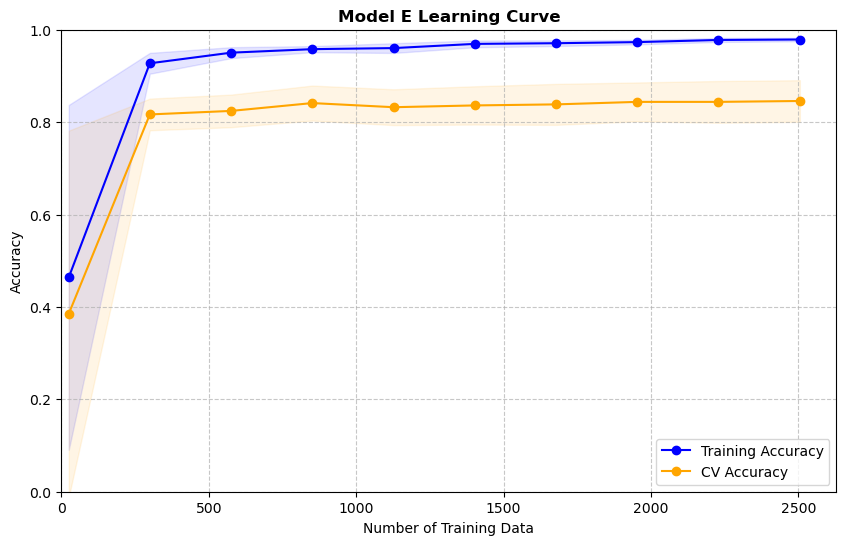

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))


shuffle_idx = np.random.permutation(len(y_train))
X_shuf = X_train_E_best[shuffle_idx]
y_shuf = y_train[shuffle_idx]
groups_train = df_desc.iloc[train_idx]['SMILES']
groups_shuf = groups_train.iloc[shuffle_idx].values

gkf = GroupKFold(n_splits=5)
train_sizes, train_scores, test_scores = learning_curve(
        model_E, X_shuf, y_shuf, cv=gkf, groups=groups_shuf, n_jobs=-1, 
        train_sizes=np.linspace(0.01, 1 , 10), scoring='accuracy'
    )
    
train_mean, train_std = np.mean(train_scores, axis=1), np.std(train_scores, axis=1)
test_mean, test_std = np.mean(test_scores, axis=1), np.std(test_scores, axis=1)

ax.plot(train_sizes, train_mean, 'o-', color="blue", label="Training Accuracy")
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="blue")
ax.plot(train_sizes, test_mean, 'o-', color="orange", label="Accuracy")
ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="orange")
    
ax.set_title("Model E Learning Curve" , fontsize=12, fontweight='bold')
ax.set_xlabel("Number of Training Data")
ax.set_ylabel("Accuracy")
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend(loc="lower right")
ax.set_xlim(left=0)
ax.set_ylim([0, 1.0]) 

In [15]:
list_matrix_vectors = [f"Matrix_Vector_M{i+1}" for i in range(X_mat.shape[1])]

selected_names_E = ['RT'] + cols_E + list_matrix_vectors

imp_E = pd.DataFrame({'Feature': selected_names_E, 'Importance': model_E.feature_importances_})

print(" MODEL E FEATURE IMPORTANCES:")
print(imp_E.sort_values(by='Importance', ascending=False).to_string(index=False))

 MODEL E FEATURE IMPORTANCES:
          Feature  Importance
   Sol_Dielectric    0.138909
     Sol_Hansen_P    0.126179
            MolWt    0.103281
     Sol_Hansen_D    0.088305
               RT    0.074406
     Sol_Hansen_H    0.067231
Matrix_Vector_M10    0.052876
 Matrix_Vector_M3    0.046820
 Matrix_Vector_M5    0.043127
 Matrix_Vector_M4    0.040461
 Matrix_Vector_M7    0.039241
 Matrix_Vector_M2    0.038705
 Matrix_Vector_M8    0.038326
 Matrix_Vector_M9    0.036912
 Matrix_Vector_M6    0.034226
 Matrix_Vector_M1    0.030993


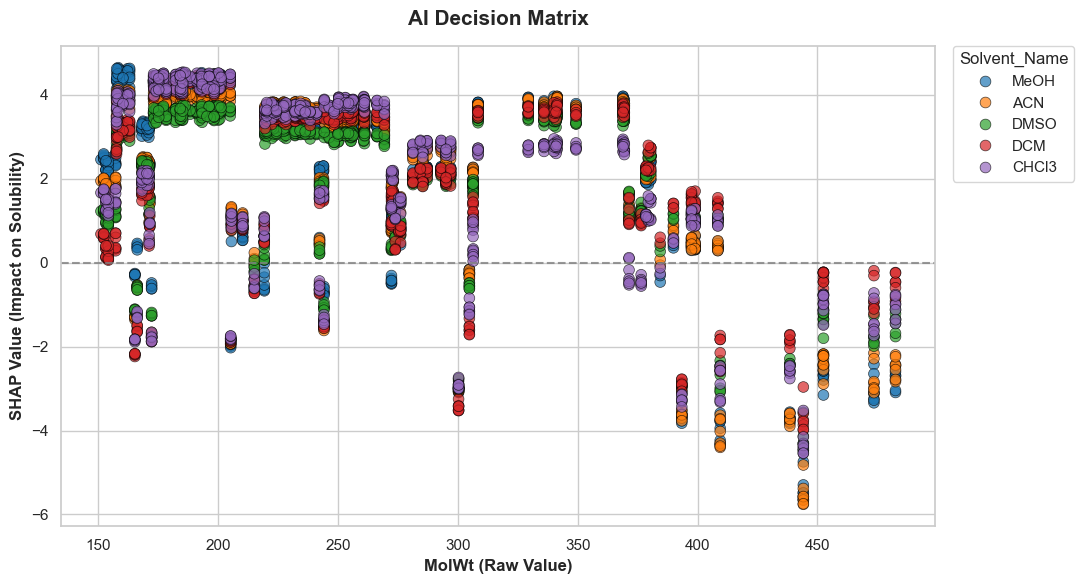

In [44]:
my_features = ['MolWt', 'Sol_Dielectric', 'Sol_Hansen_D', 'Sol_Hansen_P', 'Sol_Hansen_H']

# PLOT 1: Let's see how Molecular Weight interacts with the actual Machine Names
# (Assuming your column is named 'Matrix ID Name')
plot_custom_shap_categorical(model_E, df_desc, my_features, 
                             base_feature='MolWt', 
                             color_col='Solvent_Name')

In [ ]:
def plot_solvent_gallery_shap(model, X_matrix, df_test, feature_names, base_feature='MolWt', color_col='Matrix ID Name'):
    """
    Generates a separate SHAP plot for every unique solvent in the test set.
    """
    # 1. Initialize the Explainer once
    explainer = shap.TreeExplainer(model)
    shap_values_all = explainer.shap_values(X_matrix)
    
    # Get the index of the feature we want to plot (e.g., 'MolWt')
    feature_idx = feature_names.index(base_feature)
    
    # 2. Identify unique solvents
    solvents = df_test['Solvent_Name'].unique()
    
    for sol in solvents:
        # 3. Find the rows belonging to THIS solvent
        sol_mask = (df_test['Solvent_Name'] == sol).values
        
        # Pull out the specific SHAP values and raw values for this solvent
        sol_shap = shap_values_all[sol_mask, feature_idx]
        sol_raw_val = X_matrix[sol_mask, feature_idx]
        sol_color = df_test.iloc[sol_mask][color_col]
        
        # 4. Create the Plot
        plt.figure(figsize=(9, 5))
        
        sns.scatterplot(
            x=sol_raw_val, 
            y=sol_shap, 
            hue=sol_color, 
            palette='viridis', 
            alpha=0.8,
            edgecolor='w',
            linewidth=0.5
        )
        
        plt.axhline(0, color='black', linestyle='--', alpha=0.3)
        plt.title(f"SHAP Impact of {base_feature} in {sol}", fontsize=14)
        plt.xlabel(f"Raw {base_feature}")
        plt.ylabel("SHAP Value (Impact on Solubility)")
        plt.legend(title=color_col, bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, alpha=0.2)
        
        plt.tight_layout()
        plt.show()

🎨 Generating 5 solvent-specific plots...


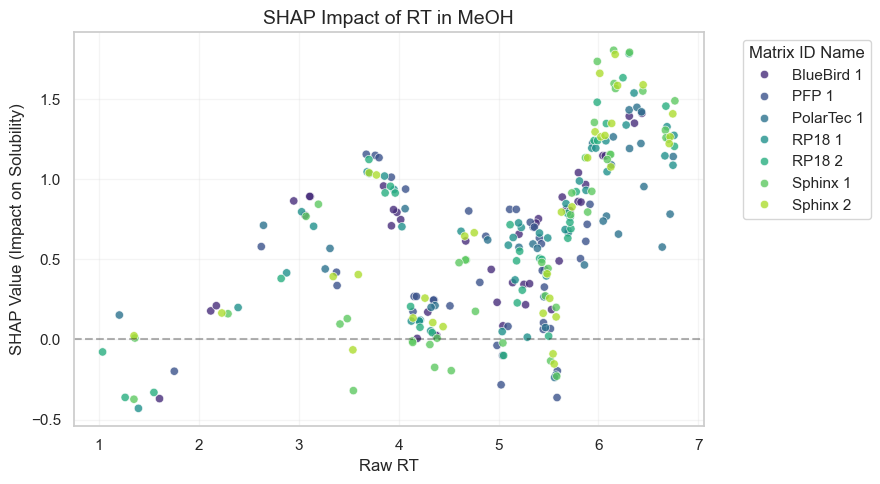

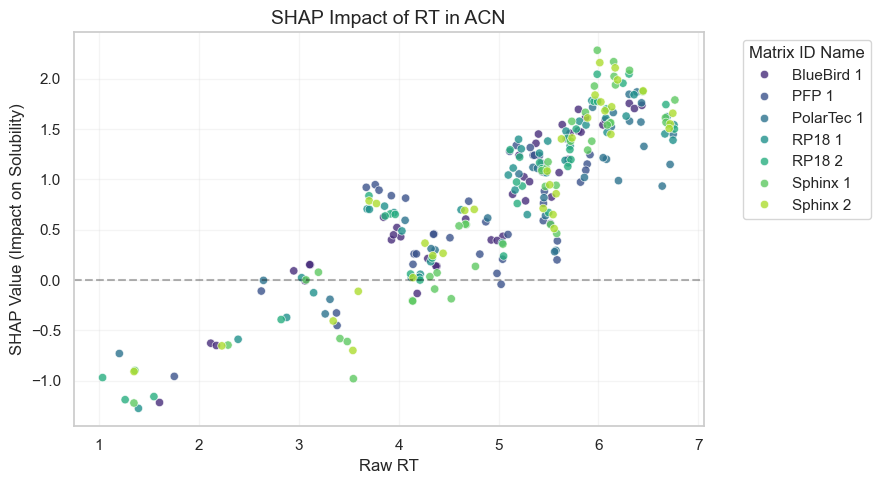

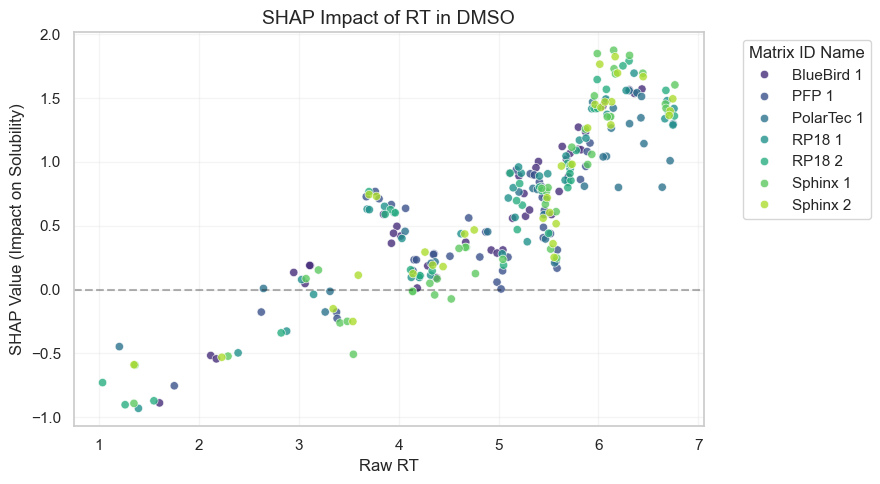

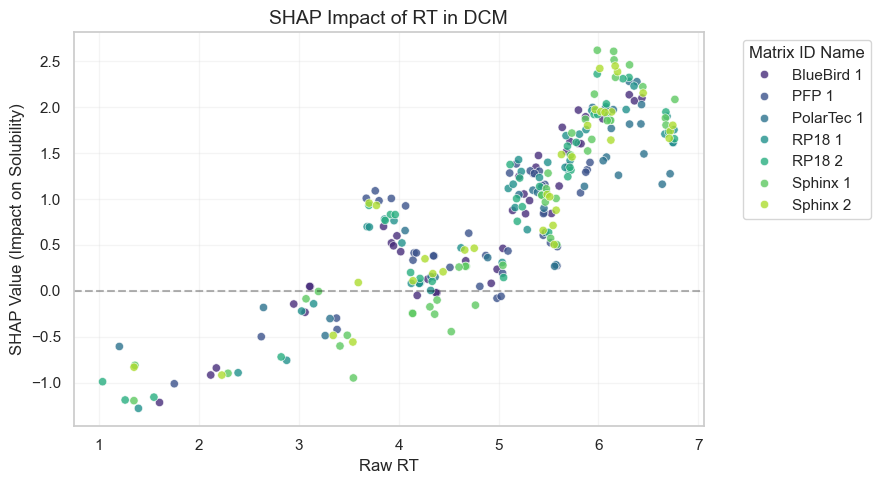

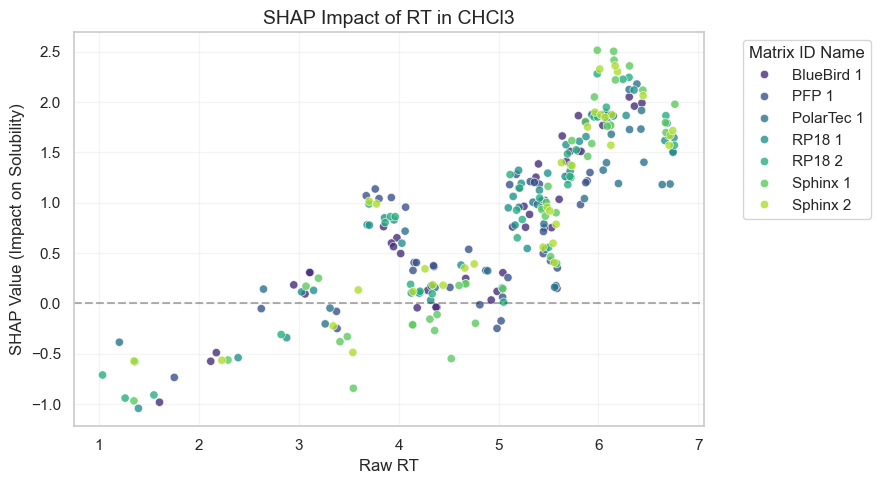

In [47]:
feature_names_E = ['RT'] + cols_E + [f"M_{i}" for i in range(X_mat.shape[1])]

plot_solvent_gallery_shap(
    model=model_E, 
    X_matrix=X_test_E_best, 
    df_test=df_desc.iloc[test_idx], # The dataframe version of your test set
    feature_names=feature_names_E,
    base_feature='RT'
)

In [45]:
def plot_hansen_impacts(model, X_matrix, df_test, feature_names, color_col='Solvent_Name'):
    """
    Plots SHAP values for the three Hansen Parameters to see how they 
    drive solubility across different solvents.
    """
    # 1. Initialize and run SHAP
    explainer = shap.TreeExplainer(model)
    shap_values_all = explainer.shap_values(X_matrix)
    
    # The parameters we want to investigate
    hansen_params = ['Sol_Hansen_D', 'Sol_Hansen_P', 'Sol_Hansen_H']
    
    # 2. Setup the Plotting Grid (1 row, 3 columns)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for i, param in enumerate(hansen_params):
        if param not in feature_names:
            print(f"⚠️ Skipping {param}: Not found in feature_names list.")
            continue
            
        # Get the index and extract values
        idx = feature_names.index(param)
        specific_shap = shap_values_all[:, idx]
        raw_values = X_matrix[:, idx]
        
        # 3. Create the Scatter Plot
        sns.scatterplot(
            x=raw_values, 
            y=specific_shap, 
            hue=df_test[color_col], 
            ax=axes[i],
            palette='Set1',
            alpha=0.6,
            edgecolor=None
        )
        
        axes[i].axhline(0, color='black', linestyle='--', alpha=0.3)
        axes[i].set_title(f"Impact of {param}", fontsize=14)
        axes[i].set_xlabel("Parameter Value")
        axes[i].set_ylabel("SHAP Value")
        axes[i].legend(title=color_col, bbox_to_anchor=(1, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

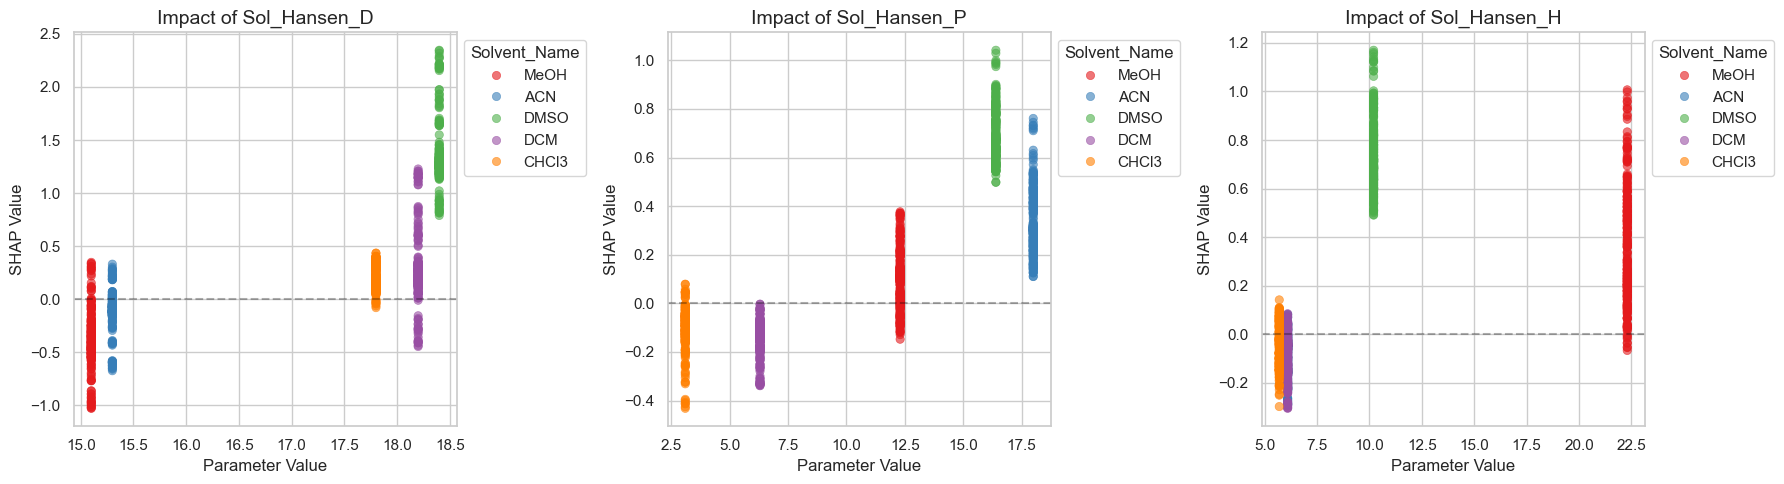

In [46]:
feature_names_E = ['RT'] + cols_E + [f"M_{i}" for i in range(X_mat.shape[1])]

plot_hansen_impacts(
    model=model_E, 
    X_matrix=X_test_E_best, 
    df_test=df_desc.iloc[test_idx], 
    feature_names=feature_names_E
)

In [34]:
def export_confidence_scores(loaded_model, df, phys_feature_list, output_filename="Model_Confidence_Scores.xlsx"):
    
    # --- 1. REBUILD THE EXACT FEATURE MATRIX ---
    X_rt = df[['RT']].values 
    X_phys = df[phys_feature_list].values 
    X_mat = np.vstack(df['Matrix_Packed_Array'].values)
    X_final = np.hstack((X_rt, X_phys, X_mat))
    
    # --- 2. GET THE PREDICTIONS AND PROBABILITIES ---
    # .predict() gives the hard 1 or 0
    predictions = loaded_model.predict(X_final)
    
    # .predict_proba() gives an array with two numbers per row:
    # [Probability of 0, Probability of 1]
    # We want the second column (index 1), which is the % chance of being Soluble.
    probabilities = loaded_model.predict_proba(X_final)[:, 1] 
    
    # --- 3. BUILD A CLEAN DATAFRAME FOR EXCEL ---
    # We are picking the most important columns to look at in Excel
    # (Assuming your molecule names/SMILES are in a column called 'SMILES')
    results_df = pd.DataFrame({
        'Molecule_SMILES': df['SMILES'],           # Change 'SMILES' if your ID column is named differently
        'Matrix_Machine': df['Matrix ID Name'],    # Just to see which machine it ran on
        'Retention_Time': df['RT'],
        'Actual_Solubility': df['Soluble'],        # What actually happened in the lab (0 or 1)
        'AI_Predicted_Class': predictions,         # What the AI guessed (0 or 1)
        'AI_Confidence_Score': probabilities       # The raw % score!
    })
    
    # --- 4. ADD A HELPFUL 'STATUS' COLUMN ---
    # Let's write a quick loop to label exactly what happened for easier sorting in Excel
    conditions = [
        (results_df['Actual_Solubility'] == 1) & (results_df['AI_Predicted_Class'] == 1),
        (results_df['Actual_Solubility'] == 0) & (results_df['AI_Predicted_Class'] == 0),
        (results_df['Actual_Solubility'] == 0) & (results_df['AI_Predicted_Class'] == 1),
        (results_df['Actual_Solubility'] == 1) & (results_df['AI_Predicted_Class'] == 0)
    ]
    choices = ['True Positive (Correct)', 'True Negative (Correct)', 
               'False Positive (Danger)', 'False Negative (Missed)']
    results_df['Result_Type'] = np.select(conditions, choices, default='Unknown')
    
    # --- 5. EXPORT TO EXCEL ---
    print(f"Saving to {output_filename}")
    
    # Save as Excel (you can also use .to_csv('filename.csv', index=False) if you prefer)
    results_df.to_excel(output_filename, index=False)
    
    return results_df

In [35]:
df_results = export_confidence_scores(my_model, df_desc, my_features)

Saving to Model_Confidence_Scores.xlsx


In [11]:
def run_hyperparameter_tournament(df, phys_feature_list):
    print("🏆 Starting the XGBoost Hyperparameter Tournament...")
    
    # --- 1. PREPARE THE DATA ---
    y = df['Soluble'].values
    X_rt = df[['RT']].values 
    X_phys = df[phys_feature_list].values 
    X_mat = np.vstack(df['Matrix_Packed_Array'].values)
    X_final = np.hstack((X_rt, X_phys, X_mat))
    
    # We use GroupKFold to ensure the same molecule (SMILES) 
    # doesn't accidentally end up in both the training and testing folds!
    gkf = GroupKFold(n_splits=5)
    groups = df['SMILES'].values
    
    # --- 2. DEFINE THE MENU (The Search Space) ---
    # The AI will randomly pick combinations from these lists
    param_grid = {
        # 1. THE ARCHITECTURE (Size and Speed)
        'n_estimators': [1000, 1500, 2000, 3000, 5000],  # Massive tree limits
        'learning_rate': [0.005, 0.01, 0.03, 0.05, 0.1], # Tiny steps for absolute precision
        'max_depth': [8, 12, 15, 20, 25, 0],             # 0 = No depth limit (Used with lossguide)
        
        # 2. THE ANTI-GREED PROTOCOLS (Micro-level feature hiding)
        'colsample_bytree': [0.3, 0.5, 0.7, 0.9],        # Hides features per tree
        'colsample_bylevel': [0.3, 0.5, 0.7, 1.0],       # Hides features per branch level
        'colsample_bynode': [0.3, 0.5, 0.7, 1.0],        # Hides features at EVERY SINGLE SPLIT
        'subsample': [0.5, 0.6, 0.8, 1.0],               # Hides rows
        
        # 3. OUTLIER & COMPLEXITY MANAGEMENT
        'min_child_weight': [1, 2, 3, 5, 7],             # 1 allows rule-making for single weird molecules
        'max_delta_step': [0, 1, 3, 5, 10],              # Prevents extreme probability updates (Great for chemistry data)
        
        # 4. THE RUTHLESS PENALTIES
        'gamma': [0, 0.05, 0.1, 0.5, 1, 5],              # Minimum loss reduction to force a split
        'reg_lambda': [0.1, 1, 2, 5, 10, 50],            # L2: Smooths out weights 
        'reg_alpha': [0, 0.01, 0.1, 1, 5, 10],           # L1: Completely deletes useless variables
        
        # 5. THE AI'S "THOUGHT PROCESS"
        'grow_policy': ['depthwise', 'lossguide']        # 'lossguide' lets the AI grow lopsided trees to hunt specific errors
    }
    
    # --- 3. INITIALIZE THE BASE MODEL ---
    scale_weight = (len(y) - sum(y)) / sum(y)
    base_model = xgb.XGBClassifier(scale_pos_weight=scale_weight, random_state=42, n_jobs=-1)
    
    # --- 4. SET UP THE TOURNAMENT ---
    # n_iter=50 means it will try 50 different random combinations from your menu
    # cv=gkf means it will test each combination 5 times using different cuts of the data
    random_search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=param_grid,
        n_iter=50,                  # Increase this to 100 if you have time and want a better result!
        scoring='accuracy',         # We are optimizing specifically for Accuracy
        cv=gkf,                     
        verbose=2,                  # Prints updates so you can watch it work
        random_state=42,
        n_jobs=-1                   # Uses all your computer's CPU cores
    )
    
    # --- 5. RUN THE BATTLE ---
    print("\n⚔️ Training 250 models (50 combos x 5 folds). This will take a few minutes...\n")
    random_search.fit(X_final, y, groups=groups)
    
    # --- 6. THE RESULTS ---
    print("\n=======================================================")
    print("🏆 TOURNAMENT WINNER FOUND!")
    print("=======================================================")
    print(f"Best Cross-Validated Accuracy: {random_search.best_score_:.4f}\n")
    print("The Ultimate Hyperparameters:")
    
    for key, value in random_search.best_params_.items():
        print(f"  {key:<20}: {value}")
        
    return random_search.best_estimator_

In [12]:
my_features = ['MolWt', 'Sol_Dielectric', 'Sol_Hansen_D', 'Sol_Hansen_P', 'Sol_Hansen_H']

# This will return the absolute best, fully-trained XGBoost model
ultimate_model = run_hyperparameter_tournament(df_desc, my_features)

🏆 Starting the XGBoost Hyperparameter Tournament...

⚔️ Training 250 models (50 combos x 5 folds). This will take a few minutes...

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END colsample_bylevel=0.5, colsample_bynode=1.0, colsample_bytree=0.7, gamma=5, grow_policy=depthwise, learning_rate=0.005, max_delta_step=10, max_depth=20, min_child_weight=7, n_estimators=3000, reg_alpha=1, reg_lambda=2, subsample=1.0; total time=   1.4s
[CV] END colsample_bylevel=0.5, colsample_bynode=1.0, colsample_bytree=0.7, gamma=5, grow_policy=depthwise, learning_rate=0.005, max_delta_step=10, max_depth=20, min_child_weight=7, n_estimators=3000, reg_alpha=1, reg_lambda=2, subsample=1.0; total time=   1.4s
[CV] END colsample_bylevel=0.5, colsample_bynode=1.0, colsample_bytree=0.7, gamma=5, grow_policy=depthwise, learning_rate=0.005, max_delta_step=10, max_depth=20, min_child_weight=7, n_estimators=3000, reg_alpha=1, reg_lambda=2, subsample=1.0; total time=   1.4s
[CV] END colsample_b

In [80]:
def execute_catboost_defection(df, phys_feature_list):

    
    # --- 1. THE HONEST SPLIT (No Cheating) ---
    splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
    train_idx, test_idx = next(splitter.split(df, groups=df['SMILES']))
    
    df_train = df.iloc[train_idx].copy()
    df_test = df.iloc[test_idx].copy()
    
    # --- 2. PREPARE DATA NATIVELY FOR CATBOOST ---
    # Look closely here: We do NOT use the 'Matrix_Packed_Array'.
    # We hand CatBoost the raw, human-readable strings!
    cat_features = ['Solvent_Name', 'Matrix ID Name']
    
    # Combine all features into one clean list
    all_features = ['RT'] + phys_feature_list + cat_features
    
    X_train = df_train[all_features]
    y_train = df_train['Soluble']
    
    X_test = df_test[all_features]
    y_test = df_test['Soluble']
    
    # --- 3. THE CATBOOST MODEL ---

    cb_model = CatBoostClassifier(
        #iterations=1000,           # Max number of trees
        ########learning_rate=0.05,        # Learning speed
        #######depth=6,                   # Tree depth
        ######cat_features=cat_features, # <-- THIS IS THE MAGIC LEVER!
        #####eval_metric='Accuracy',
        ####verbose=200,               # Print update every 200 trees
        ###random_seed=65
        ##iterations=1500,           # maximum number of trees the AI is allowed to build    
        #depth=8,                   # variables the AI can combine into a single "thought." A depth of 2 means "If heavy AND in DCM"
        learning_rate = 0.01,
        cat_features=cat_features,
        scale_pos_weight=scale_weight, eval_metric='Accuracy',
        verbose=200,               
        random_seed=56,
        bagging_temperature=1.5,
        random_strength=1
    )
    
    # CatBoost has a brilliant feature: we can pass the Test Set in during training.
    # It won't cheat and learn from it, but it WILL use it to stop training 
    # the exact millisecond it starts overfitting!
    cb_model.fit(
        X_train, y_train,
        eval_set=(X_test, y_test),
        early_stopping_rounds=50 
    )
    
    # --- 4. THE TRUE REPORT CARD ---

    y_pred = cb_model.predict(X_test)
    
    results_df = pd.DataFrame({
        'Solvent': df_test['Solvent_Name'],
        'Actual': y_test,
        'Predicted': y_pred
    })
    
    solvent_grades = []
    for solvent, group in results_df.groupby('Solvent'):
        acc = accuracy_score(group['Actual'], group['Predicted'])
        prec = precision_score(group['Actual'], group['Predicted'], zero_division=0) 
        
        solvent_grades.append({
            'Solvent': solvent,
            'Unseen_Molecules_Tested': len(group),
            'True_Accuracy': round(acc * 100, 2),
            'True_Precision': round(prec * 100, 2)
        })
        
    report_card = pd.DataFrame(solvent_grades).sort_values(by='True_Accuracy', ascending=True).reset_index(drop=True)
    
    display(report_card)
    return cb_model, report_card

In [81]:
my_features = ['MolWt', 'Sol_Dielectric', 'Sol_Hansen_D', 'Sol_Hansen_P', 'Sol_Hansen_H']

# Run the Defection!
catboost_model, cb_report = execute_catboost_defection(df_desc, my_features)

0:	learn: 0.7796363	test: 0.6488045	best: 0.6488045 (0)	total: 3.5ms	remaining: 3.49s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.6917682119
bestIteration = 4

Shrink model to first 5 iterations.


,Solvent,Unseen_Molecules_Tested,True_Accuracy,True_Precision
0,MeOH,186,44.62,98.59
1,DCM,186,55.91,85.57
2,CHCl3,186,60.75,97.87
3,ACN,186,62.90,93.69
4,DMSO,186,100.00,100.00


In [22]:
matrix_vectors_df = pd.DataFrame(
    df_desc['Matrix_Packed_Array'].tolist(),
    # We dynamically name them Matrix_Vector_1, Matrix_Vector_2, etc.
    columns=[f"Matrix_Vector_{i+1}" for i in range(len(df_desc['Matrix_Packed_Array'].iloc[0]))]
)

df_desc = pd.concat([df_desc.reset_index(drop=True), matrix_vectors_df.reset_index(drop=True)], axis=1)

In [96]:
cat_cols = ['Solvent_Name', 'Matrix ID Name']
cont_cols = ['RT', 'MolWt', 'Sol_Dielectric', 'Sol_Hansen_D', 'Sol_Hansen_P', 'Sol_Hansen_H'] 
vector_cols = matrix_vectors_df.columns.tolist()
all_cols = cont_cols + vector_cols + cat_cols

# We slice the original dataframe using the exact same train_idx/test_idx you made
X_train_cb = df_desc.iloc[train_idx][all_cols].copy()
y_train_cb = df_desc.iloc[train_idx]['Soluble'].copy()

X_test_cb = df_desc.iloc[test_idx][all_cols].copy()
y_test_cb = df_desc.iloc[test_idx]['Soluble'].copy()

# CatBoost can handle raw text, but it hates Python 'NaN' or None values in categorical columns.
X_train_cb[cat_cols] = X_train_cb[cat_cols].fillna('Missing')
X_test_cb[cat_cols] = X_test_cb[cat_cols].fillna('Missing')

model_cb = CatBoostClassifier(
    iterations=2000,           # maximum number of trees the AI is allowed to build    
    depth=8,                   # variables the AI can combine into a single "thought." A depth of 2 means "If heavy AND in DCM"
    learning_rate = 0.1,
    cat_features=cat_cols,
    scale_pos_weight=scale_weight, 
    eval_metric='Accuracy',
    verbose=200,               
    random_seed=56,
    
)

model_cb.fit(X_train_cb, y_train_cb,
    eval_set=(X_test_cb, y_test_cb), # Uses the test set to stop early if it overfits
    early_stopping_rounds=100)

y_pred_cb = model_cb.predict(X_test_cb)

print(f"Accuracy:  {accuracy_score(y_test_cb, y_pred_cb):.4f}")
print(f"Precision: {precision_score(y_test_cb, y_pred_cb, zero_division=0):.4f}\n")

0:	learn: 0.7805137	test: 0.6812425	best: 0.6812425 (0)	total: 15.2ms	remaining: 30.4s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.6946838824
bestIteration = 1

Shrink model to first 2 iterations.
Accuracy:  0.7569
Precision: 0.9459



In [98]:

joblib.dump(model_cb, 'final_model.joblib')
print("Export complete!")

Export complete!


In [114]:
# 1. BUILD THE GRADING DATAFRAME
# We map CatBoost's predictions directly back to the physical solvent names
results_cb_df = pd.DataFrame({
    'Solvent': X_test_cb['Solvent_Name'],
    'Actual': y_test_cb.values,            # The real lab result
    'Predicted': y_pred_cb                 # What CatBoost guessed
})

# 2. CALCULATE THE GRADES
cb_solvent_grades = []

for solvent, group in results_cb_df.groupby('Solvent'):
    acc = accuracy_score(group['Actual'], group['Predicted'])
    prec = precision_score(group['Actual'], group['Predicted'], zero_division=0) 
    
    cb_solvent_grades.append({
        'Solvent': solvent,
        'Unseen_Molecules_Tested': len(group),
        'CatBoost_Accuracy': round(acc * 100, 2),
        'CatBoost_Precision': round(prec * 100, 2)
    })
    
# 3. FORMAT AND DISPLAY
cb_report_card = pd.DataFrame(cb_solvent_grades)
cb_report_card = cb_report_card.sort_values(by='CatBoost_Accuracy', ascending=True).reset_index(drop=True)

print("📋 THE FINAL CATBOOST REPORT CARD (Unseen Test Data):")
display(cb_report_card)

📋 THE FINAL CATBOOST REPORT CARD (Unseen Test Data):


,Solvent,Unseen_Molecules_Tested,CatBoost_Accuracy,CatBoost_Precision
0,MeOH,269,82.90,88.89
1,ACN,269,88.10,89.39
2,DCM,269,88.85,88.68
3,CHCl3,269,89.96,91.12
4,DMSO,269,98.88,98.88


In [128]:
cb_importances = model_cb.get_feature_importance()
imp_cb = pd.DataFrame({
    'Feature': X_train_cb.columns, 
    'Importance': cb_importances
})

# Sort and display
display(imp_cb.sort_values(by='Importance', ascending=False).reset_index(drop=True))

,Feature,Importance
0,MolWt,33.223251
1,Sol_Dielectric,15.187835
2,RT,14.321886
3,Sol_Hansen_D,10.961391
4,Sol_Hansen_H,9.539266
5,Sol_Hansen_P,8.210030
6,Solvent_Name,2.975430
7,Matrix_Vector_9,1.025650
8,Matrix_Vector_3,0.977703
9,Matrix_Vector_4,0.713729


In [29]:
def plot_catboost_shap_categorical(model, df, all_cols, cat_cols, base_feature='MolWt', color_col='Matrix ID Name'):

    
    # --- 1. PREPARE THE DATA ---
    # We extract the exact columns and fill missing text values so CatBoost doesn't panic
    X_shap = df[all_cols].copy()
    X_shap[cat_cols] = X_shap[cat_cols].fillna('Missing')
    
    # We must wrap the data in a CatBoost 'Pool' so it knows which columns are text
    pool = catboost.Pool(data=X_shap, cat_features=cat_cols)
    
    # --- 2. EXTRACT SHAP NATIVELY ---
    # This uses CatBoost's internal C++ engine. It is lightning fast!
    shap_values_raw = model.get_feature_importance(pool, type='ShapValues')
    
    # CatBoost returns a matrix where the very last column is the "Base Expected Value"
    # We slice off the last column ( [:, :-1] ) to leave only the actual feature impacts
    shap_values = shap_values_raw[:, :-1] 
    
    # --- 3. ISOLATE THE FEATURE WE WANT TO PLOT ---
    feature_idx = all_cols.index(base_feature)
    specific_shap_values = shap_values[:, feature_idx]
    
    # --- 4. BUILD A CLEAN DATAFRAME FOR SEABORN ---
    plot_df = pd.DataFrame({
        base_feature: X_shap[base_feature],
        'SHAP Value': specific_shap_values,
        color_col: X_shap[color_col]
    })
    
    # --- 5. RENDER THE PLOT ---
    plt.figure(figsize=(10, 6))
    
    sns.scatterplot(
        data=plot_df, 
        x=base_feature, 
        y='SHAP Value', 
        hue=color_col, 
        palette='tab10',   # A distinct color palette
        alpha=0.7,         # Makes the dots slightly transparent so we can see overlaps
        edgecolor=None
    )
    
    # Draw the baseline at 0.0
    plt.axhline(0, color='black', linestyle='--', alpha=0.5)
    
    # Clean up the visuals
    plt.title(f"CatBoost SHAP: Impact of {base_feature} by {color_col}", fontsize=14, pad=15)
    plt.xlabel(base_feature, fontsize=12)
    plt.ylabel('SHAP Value (Impact on predicted Soluble)', fontsize=12)
    
    # Move the legend outside the plot so it doesn't cover up data
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title=color_col)
    plt.tight_layout()
    plt.show()

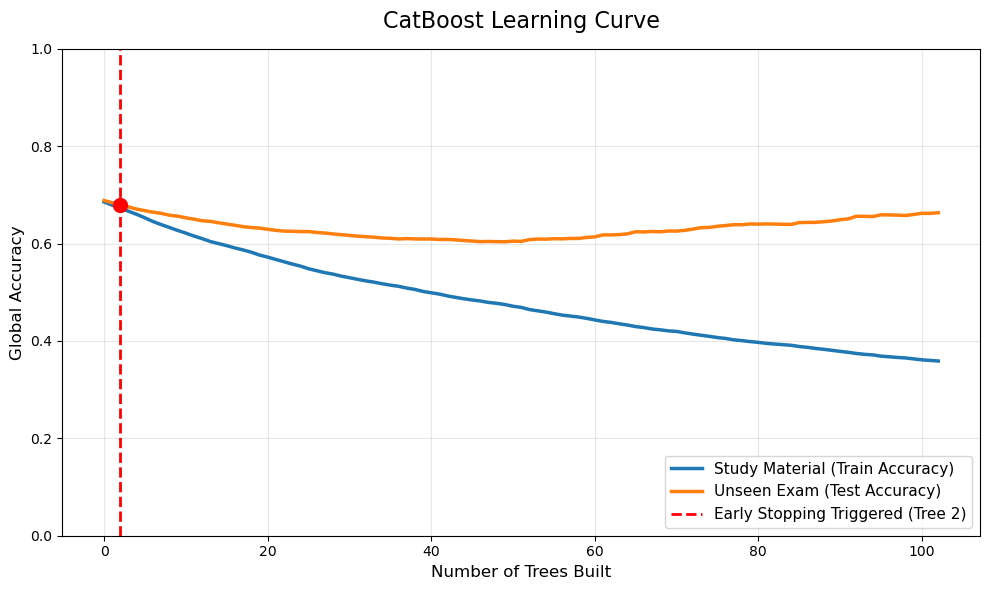

In [51]:
history = model_cb.evals_result_

# 2. Pull the specific accuracy arrays
train_error = history['learn']['Logloss']
test_error = history['validation']['Logloss']

# 3. Find the exact tree where the AI peaked before overfitting
best_tree = model_cb.get_best_iteration()

# --- PLOTTING ---
plt.figure(figsize=(10, 6))

# Plot the curves
plt.plot(train_error, label='Study Material (Train Accuracy)', color='#1f77b4', linewidth=2.5)
plt.plot(test_error, label='Unseen Exam (Test Accuracy)', color='#ff7f0e', linewidth=2.5)

# Draw the "Emergency Brake" line
if best_tree is not None:
    plt.axvline(x=best_tree, color='red', linestyle='--', linewidth=2,
                label=f'Early Stopping Triggered (Tree {best_tree})')
    # Mark the peak point
    plt.scatter(best_tree, test_error[best_tree], color='red', s=100, zorder=5)

# Clean up visuals
plt.ylim(0, 1)
plt.title('CatBoost Learning Curve', fontsize=16, pad=15)
plt.xlabel('Number of Trees Built', fontsize=12)
plt.ylabel('Global Accuracy', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right', fontsize=11)

plt.tight_layout()
plt.show()

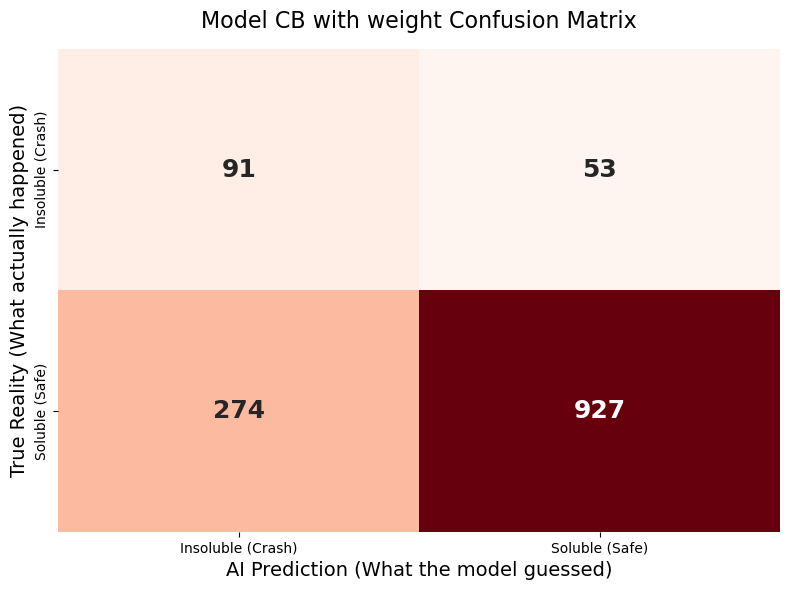

In [92]:
cm = confusion_matrix(y_test_cb, y_pred_cb)

plt.figure(figsize=(8, 6))
# Using a 'Reds' colormap to highlight the danger zones
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=['Insoluble (Crash)', 'Soluble (Safe)'],
            yticklabels=['Insoluble (Crash)', 'Soluble (Safe)'],
            annot_kws={"size": 18, "weight": "bold"})

plt.title('Model CB with weight Confusion Matrix', fontsize=16, pad=15)
plt.xlabel('AI Prediction (What the model guessed)', fontsize=14)
plt.ylabel('True Reality (What actually happened)', fontsize=14)
plt.tight_layout()
plt.show()

In [59]:
def run_bin_analysis(df_test, y_true, y_pred, feature_name, num_bins=8):

    
    # 1. Create a DataFrame for analysis
    results = pd.DataFrame({
        'Feature_Value': df_test[feature_name].values,
        'Actual': y_true.values,
        'Predicted': y_pred
    })
    
    # 2. Chop the continuous feature into bins
    results['Bin'] = pd.cut(results['Feature_Value'], bins=num_bins)
    
    # 3. Calculate metrics per bin
    bin_stats = []
    for bin_interval, group in results.groupby('Bin', observed=False):
        if len(group) == 0:
            continue
            
        acc = accuracy_score(group['Actual'], group['Predicted'])
        errors = len(group) - sum(group['Actual'] == group['Predicted'])
        
        bin_stats.append({
            'Bin_Range': str(bin_interval),
            'Bin_Center': bin_interval.mid,
            'Total_Molecules': len(group),
            'Errors': errors,
            'Accuracy': acc * 100
        })
        
    stats_df = pd.DataFrame(bin_stats)
    
    # 4. PLOTTING: Dual-Axis Chart
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    # Bar Chart (Sample Size) on left Y-axis
    sns.barplot(data=stats_df, x='Bin_Range', y='Total_Molecules', color='lightgrey', ax=ax1, alpha=0.7)
    ax1.set_ylabel('Number of Molecules in Bin', color='grey', fontsize=12)
    ax1.tick_params(axis='y', labelcolor='grey')
    ax1.set_xlabel(f'{feature_name} Bins', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    
    # Line Chart (Accuracy) on right Y-axis
    ax2 = ax1.twinx()
    sns.lineplot(data=stats_df, x='Bin_Range', y='Accuracy', color='red', marker='o', 
                 linewidth=3, markersize=10, ax=ax2)
    ax2.set_ylabel('Accuracy (%)', color='red', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='red')
    
    # Add a baseline for the global average
    global_acc = accuracy_score(y_true, y_pred) * 100
    ax2.axhline(global_acc, color='red', linestyle='--', alpha=0.3, label=f'Global Avg ({global_acc:.1f}%)')
    
    # Fix Y-axis to see the drops clearly
    ax2.set_ylim(min(40, stats_df['Accuracy'].min() - 10), 100)
    
    plt.title(f'Error Distribution Across {feature_name}', fontsize=16, pad=15)
    plt.tight_layout()
    plt.show()

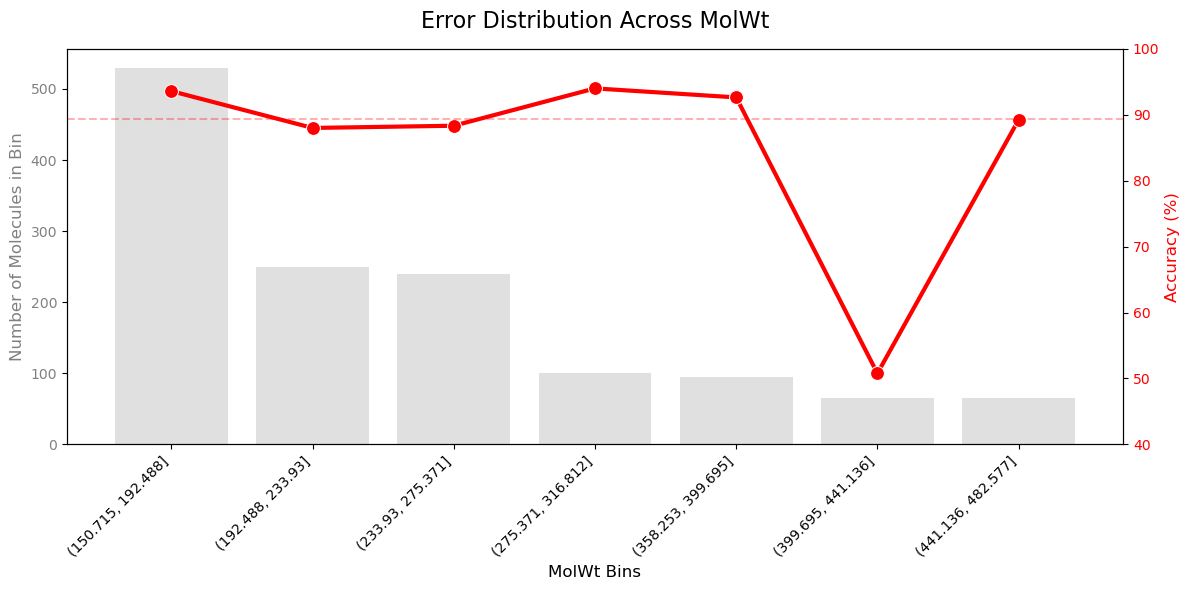

In [66]:
run_bin_analysis(X_test_cb, y_test_cb, y_pred_cb, feature_name='MolWt', num_bins=8) # without weight

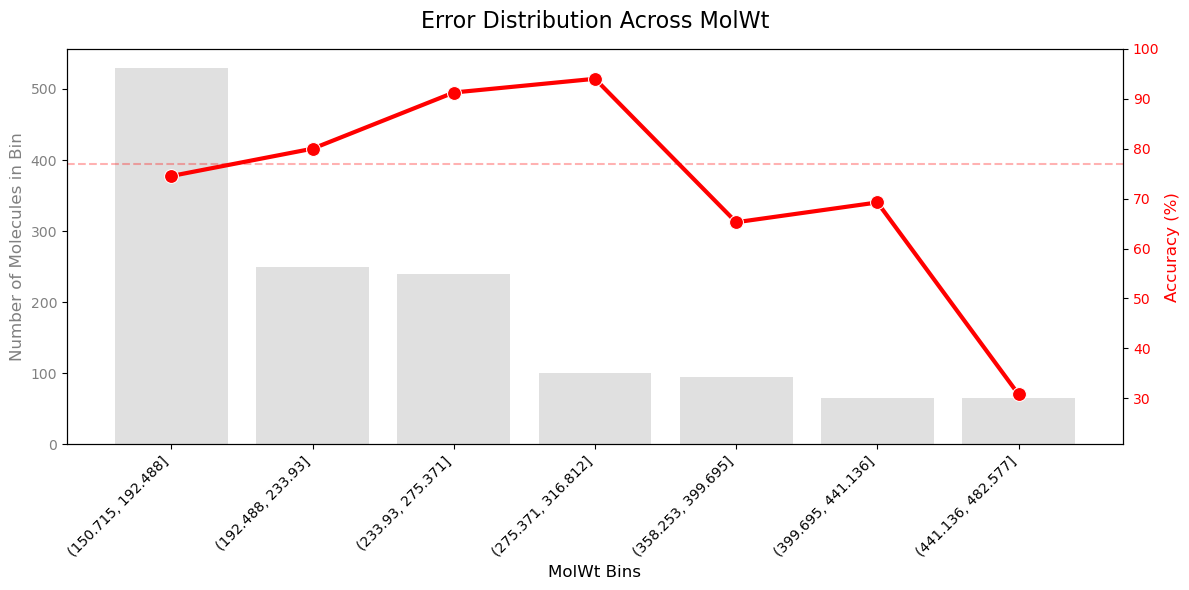

In [ ]:
run_bin_analysis(X_test_cb, y_test_cb, y_pred_cb, feature_name='MolWt', num_bins=8) # with weight

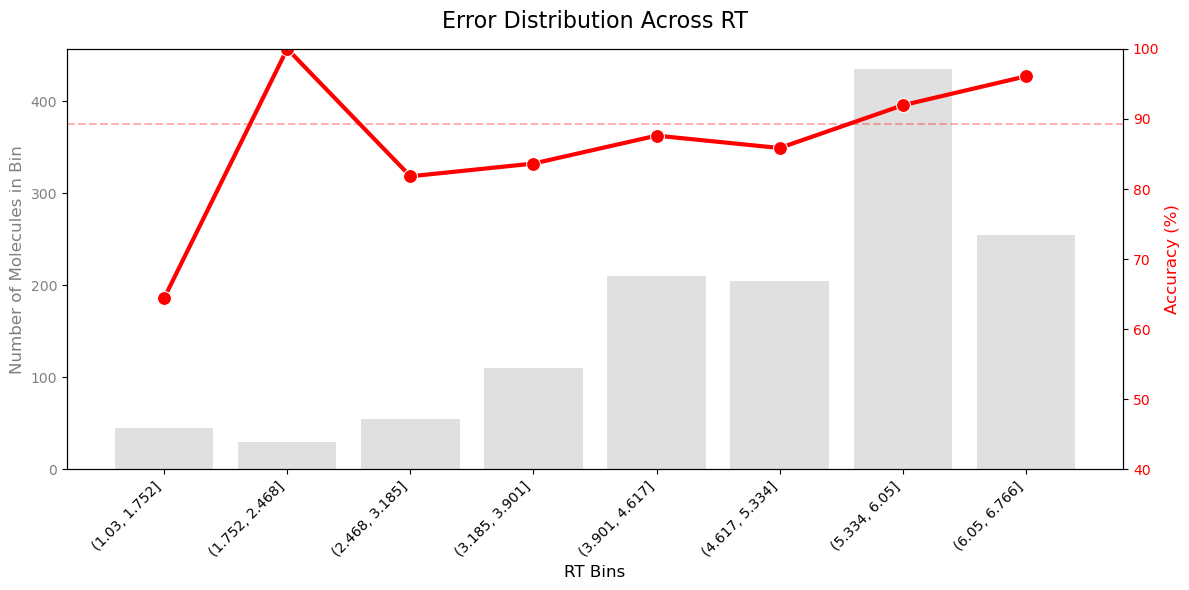

In [67]:
run_bin_analysis(X_test_cb, y_test_cb, y_pred_cb, feature_name='RT', num_bins=8)

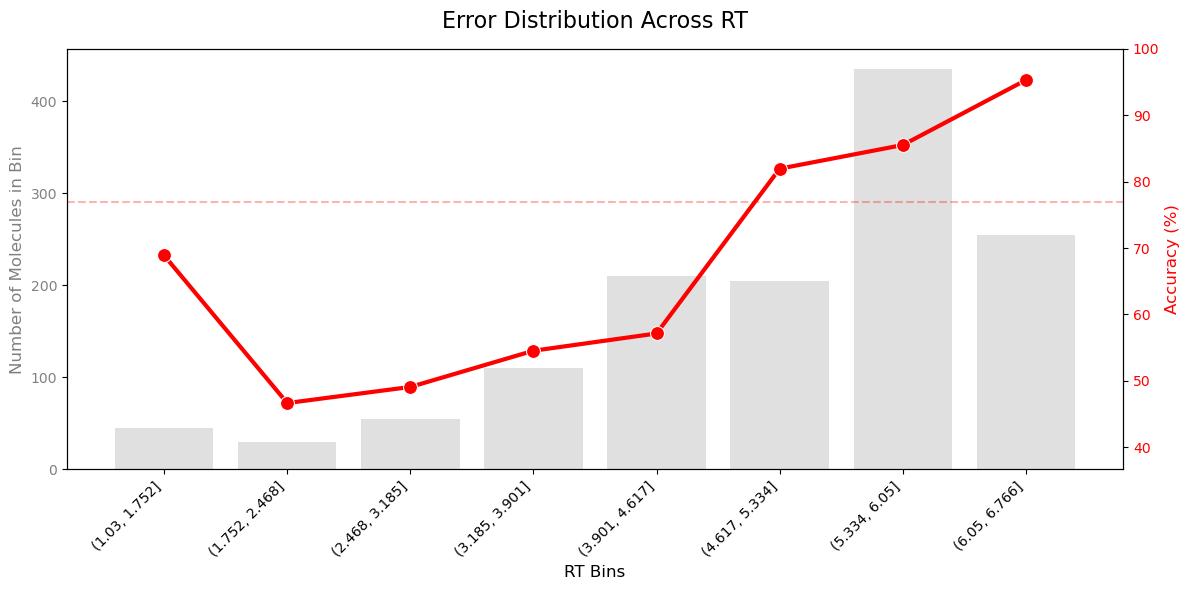

In [ ]:
run_bin_analysis(X_test_cb, y_test_cb, y_pred_cb, feature_name='RT', num_bins=8) # with weight

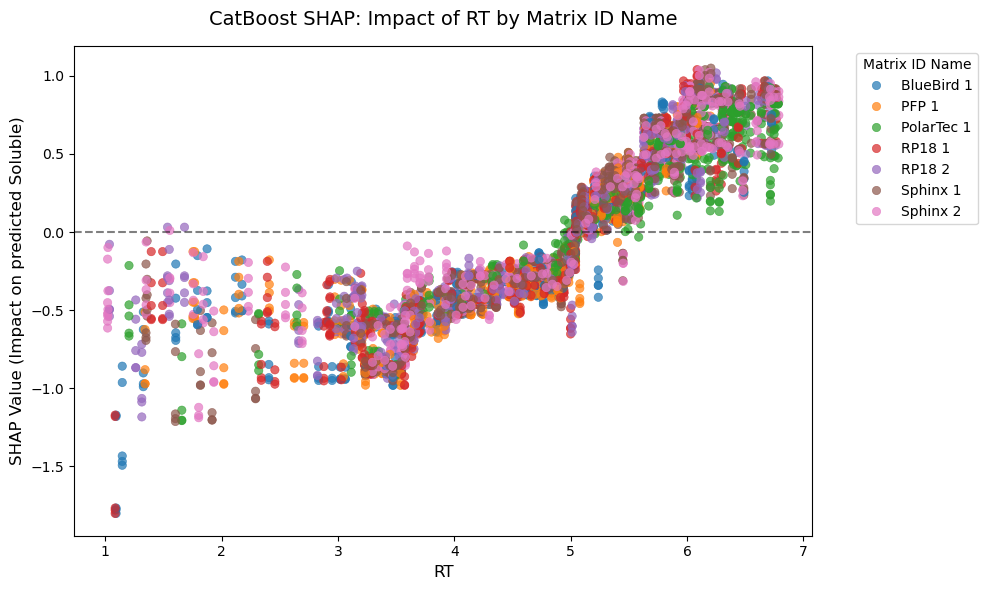

In [ ]:
cat_cols = ['Solvent_Name', 'Matrix ID Name']
cont_cols = ['RT', 'MolWt', 'Sol_Dielectric', 'Sol_Hansen_D', 'Sol_Hansen_P', 'Sol_Hansen_H'] 
all_cols = cont_cols + cat_cols

plot_catboost_shap_categorical(
    model_cb, 
    df_desc, 
    all_cols, 
    cat_cols, 
    base_feature='RT', 
    color_col='Matrix ID Name'
)

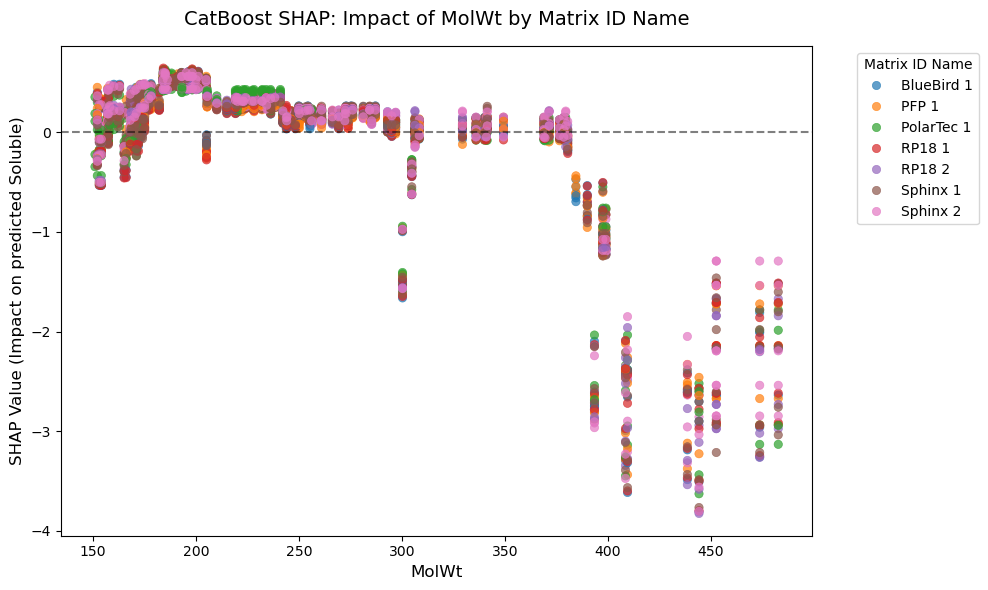

In [31]:
plot_catboost_shap_categorical(
    model_cb, 
    df_desc, 
    all_cols, 
    cat_cols, 
    base_feature='MolWt', 
    color_col='Matrix ID Name'
)

In [35]:
def plot_data_size_learning_curve(X_train, y_train, X_test, y_test, cat_cols):
    
    # The fractions of data we will feed the AI
    fractions = [0.01,0.1, 0.2, 0.4, 0.6, 0.8, 1.0]
    
    train_scores = []
    test_scores = []
    data_sizes = []
    scale_weight = (len(y_train) - sum(y_train)) / sum(y_train)
    for frac in fractions:
        # Calculate how many rows this fraction represents
        n_samples = int(len(X_train) * frac)
        data_sizes.append(n_samples)
    
        
        # Safely subset the training data without losing the index alignment
        X_subset, y_subset = resample(X_train, y_train, n_samples=n_samples, random_state=42, stratify=y_train)
        
        # Initialize a fresh, empty brain for every step
        # (Using the optimal Goldilocks/Surgical parameters)
        model = CatBoostClassifier(
            iterations=1500,
            depth=7,
            cat_features=cat_cols,
            eval_metric='Accuracy',
            verbose=False, # Turn off tree printing so it doesn't flood the screen
            random_seed=64,
       
            bagging_temperature=1,
            random_strength=1.5
        )
        
        # Train with early stopping
        model.fit(
            X_subset, y_subset,
            eval_set=(X_test, y_test),
            early_stopping_rounds=50
        )
        
        # Record the grades
        train_pred = model.predict(X_subset)
        test_pred = model.predict(X_test)
        
        train_scores.append(accuracy_score(y_subset, train_pred))
        test_scores.append(accuracy_score(y_test, test_pred))

    # --- PLOTTING ---

    plt.figure(figsize=(10, 6))
    
    plt.plot(data_sizes, train_scores, 'o-', color='#1f77b4', linewidth=2.5, markersize=8, label='Study Material (Train Accuracy)')
    plt.plot(data_sizes, test_scores, 's-', color='#ff7f0e', linewidth=2.5, markersize=8, label='Unseen Exam (Test Accuracy)')
    
    # Lock the Y-axis so we get the absolute perspective
    plt.ylim(0, 1)
    
    plt.title('Data Size Learning Curve: Does the AI need more data?', fontsize=16, pad=15)
    plt.xlabel('Number of Molecules Used for Training', fontsize=12)
    plt.ylabel('Global Accuracy (0.0 to 1.0)', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(loc='lower right', fontsize=11)
    
    plt.tight_layout()
    plt.show()

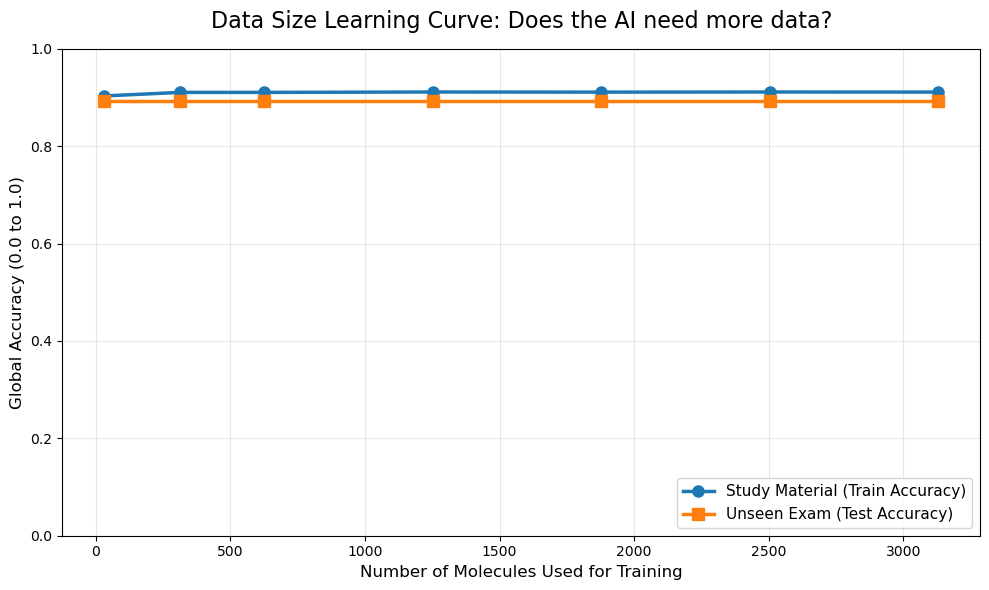

In [36]:
plot_data_size_learning_curve(X_train_cb, y_train_cb, X_test_cb, y_test_cb, cat_cols)

In [28]:
def plot_catboost_solvent_gallery(model, X_test_df, base_feature='MolWt', color_col='Matrix ID Name'):
    """
    Generates a separate SHAP plot for every unique solvent in the CatBoost test set.
    """

    
    # 1. Initialize Explainer directly on the DataFrame
    explainer = shap.TreeExplainer(model)
    shap_values_all = explainer.shap_values(X_test_df)
    
    # 2. Get the exact column index automatically
    feature_idx = X_test_df.columns.get_loc(base_feature)
    
    # 3. Identify unique solvents natively
    solvents = X_test_df['Solvent_Name'].unique()
    


    for sol in solvents:
        # 4. Filter for THIS solvent
        sol_mask = X_test_df['Solvent_Name'] == sol
        
        # Pull out the specific SHAP values and raw values
        sol_shap = shap_values_all[sol_mask, feature_idx]
        sol_raw_val = X_test_df.loc[sol_mask, base_feature]
        sol_color = X_test_df.loc[sol_mask, color_col]
        
        # 5. Create the Plot
        plt.figure(figsize=(9, 5))
        
        sns.scatterplot(
            x=sol_raw_val, 
            y=sol_shap, 
            hue=sol_color, 
            palette='viridis', 
            alpha=0.8,
            edgecolor='w',
            linewidth=0.5
        )
        
        plt.axhline(0, color='black', linestyle='--', alpha=0.3)
        plt.title(f"SHAP Impact of {base_feature} in {sol}", fontsize=14)
        plt.xlabel(f"Raw {base_feature}")
        plt.ylabel("SHAP Value (Impact on Solubility)")
        
        # Move legend outside the plot so it doesn't cover data
        plt.legend(title=color_col, bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, alpha=0.2)
        
        plt.tight_layout()
        plt.show()

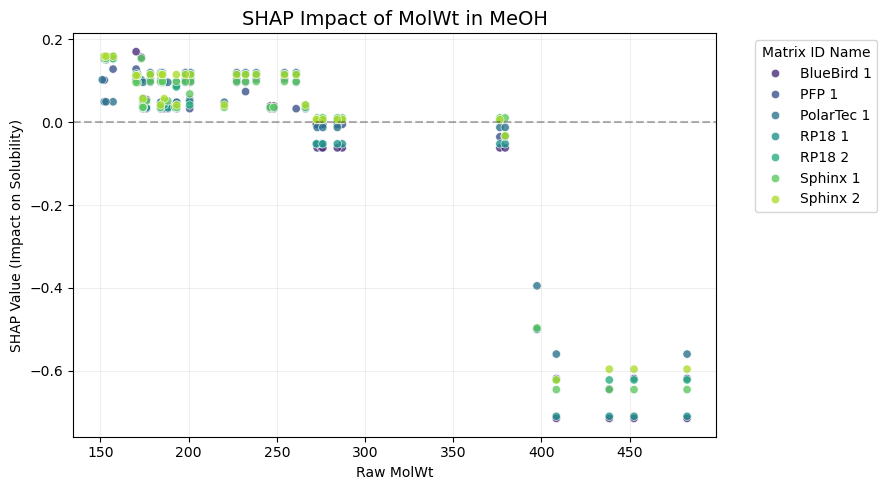

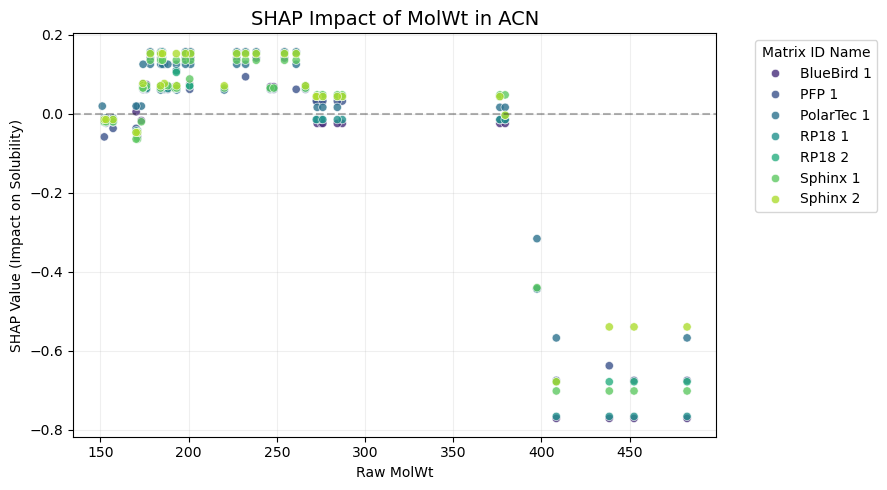

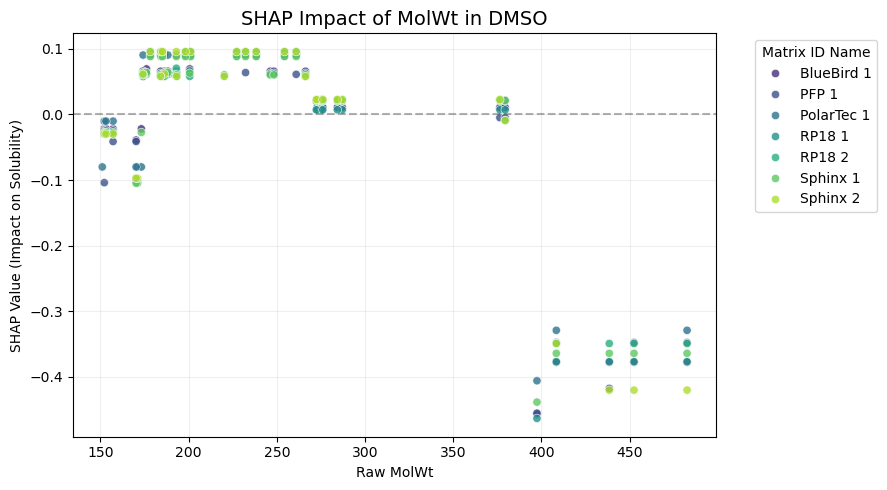

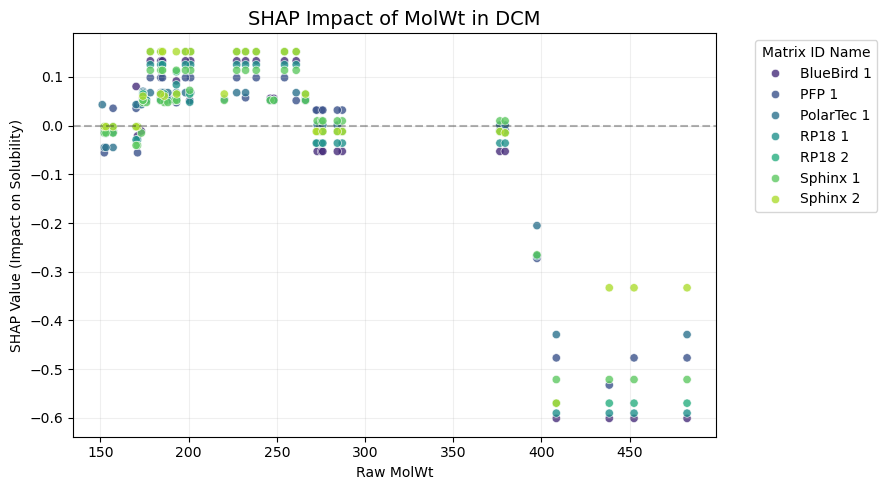

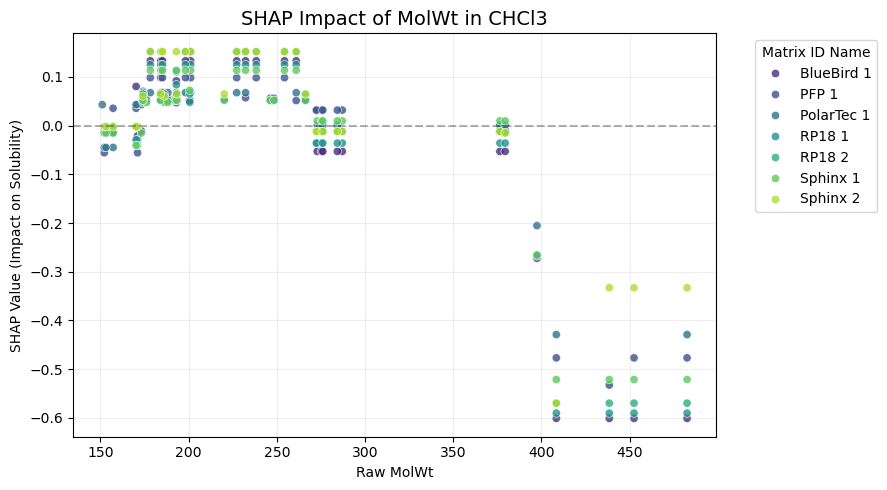

In [29]:
plot_catboost_solvent_gallery(
    model=model_cb, 
    X_test_df=X_test_cb, 
    base_feature='MolWt',       # You can change this to 'RT' or 'Matrix_Vector_1' later!
    color_col='Matrix ID Name' 
)

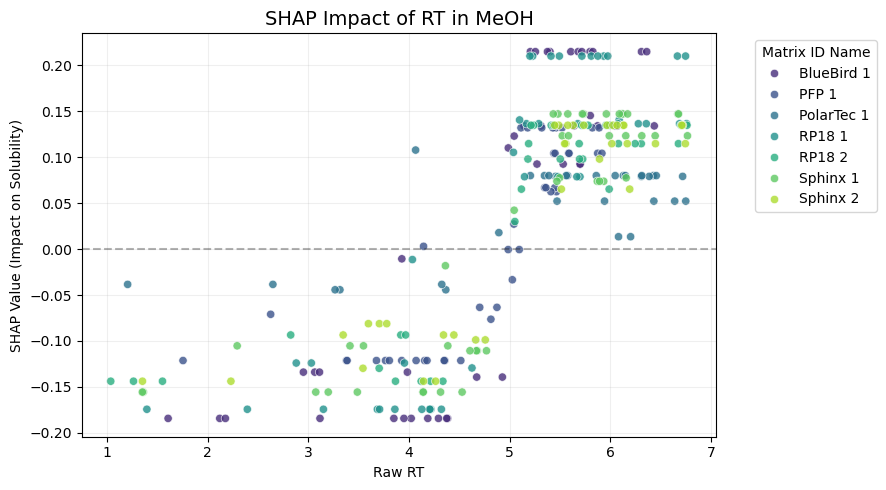

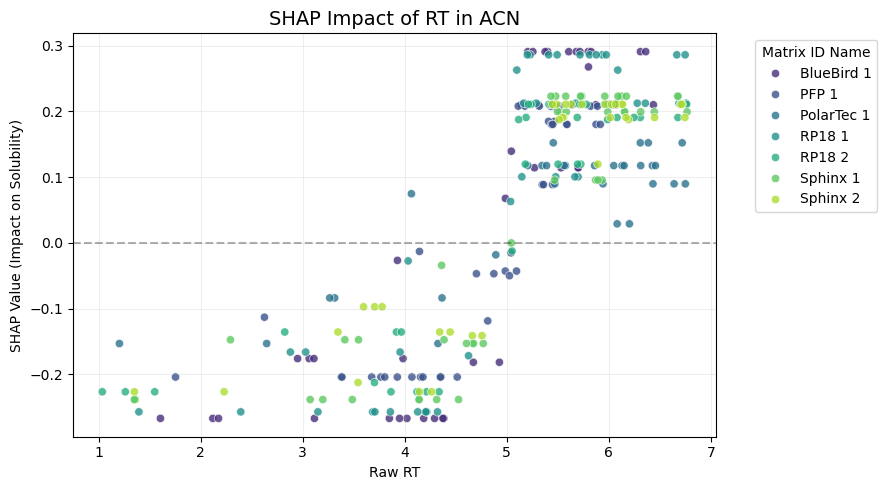

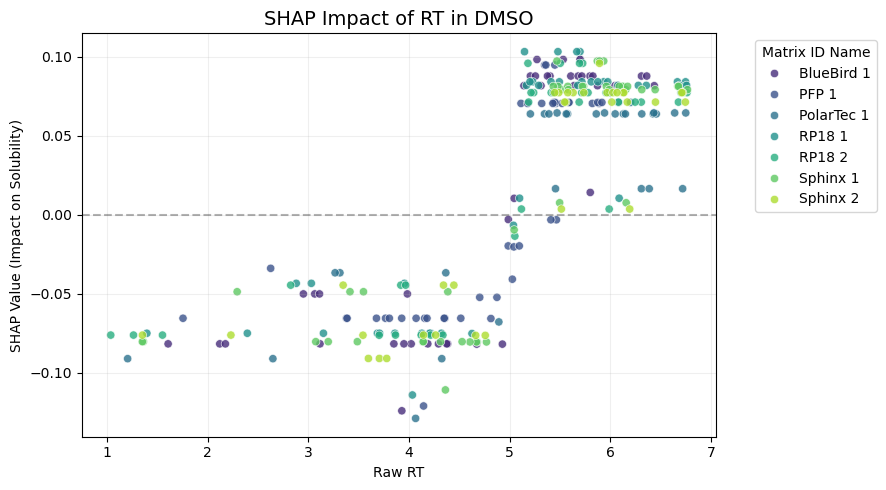

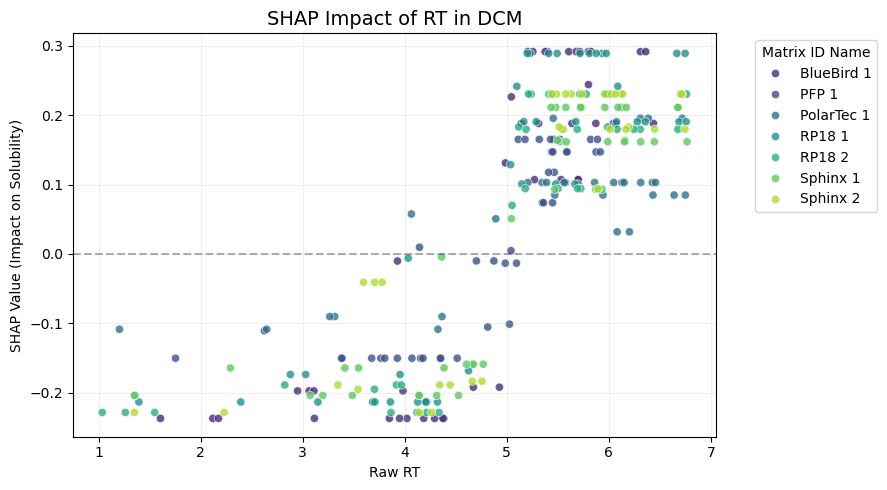

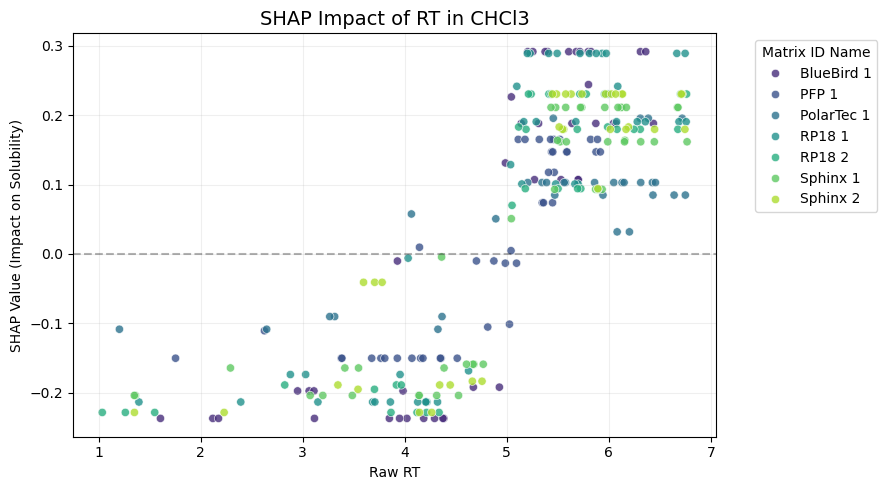

In [30]:
plot_catboost_solvent_gallery(
    model=model_cb, 
    X_test_df=X_test_cb, 
    base_feature='RT',       # You can change this to 'RT' or 'Matrix_Vector_1' later!
    color_col='Matrix ID Name' 
)

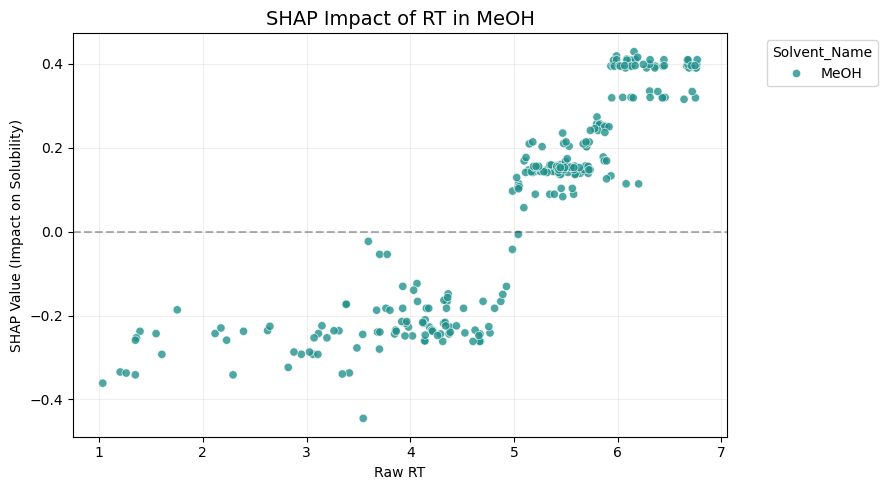

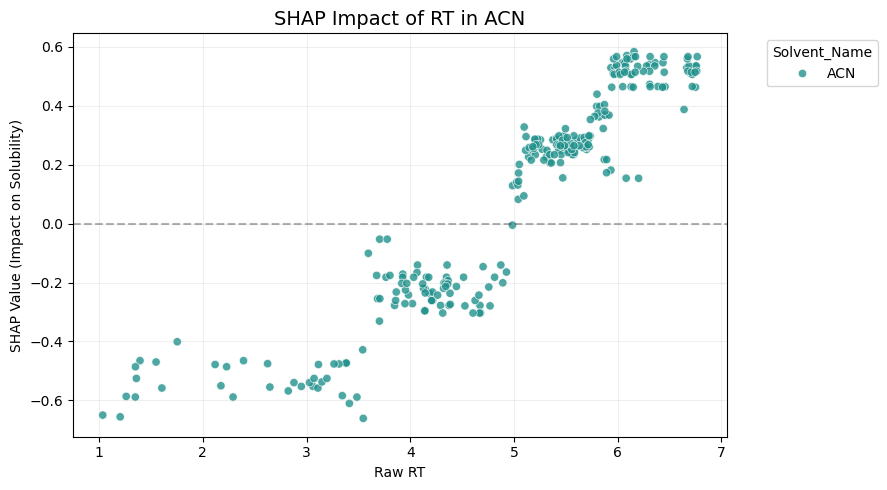

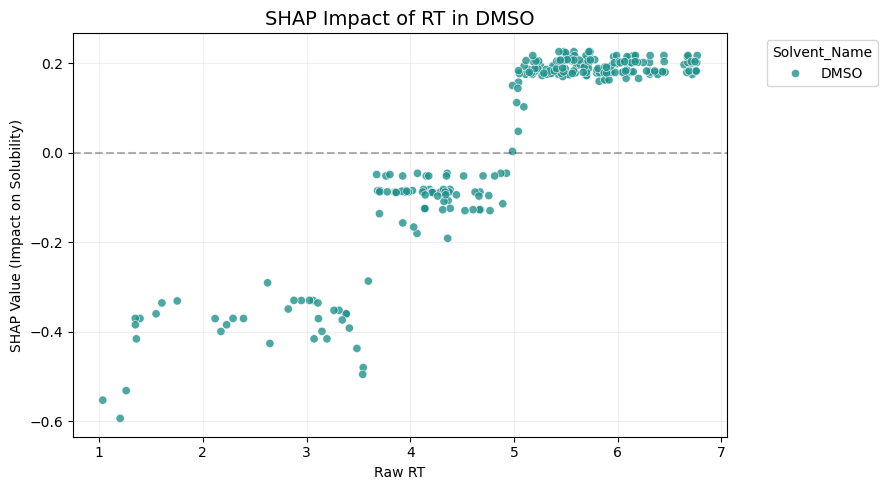

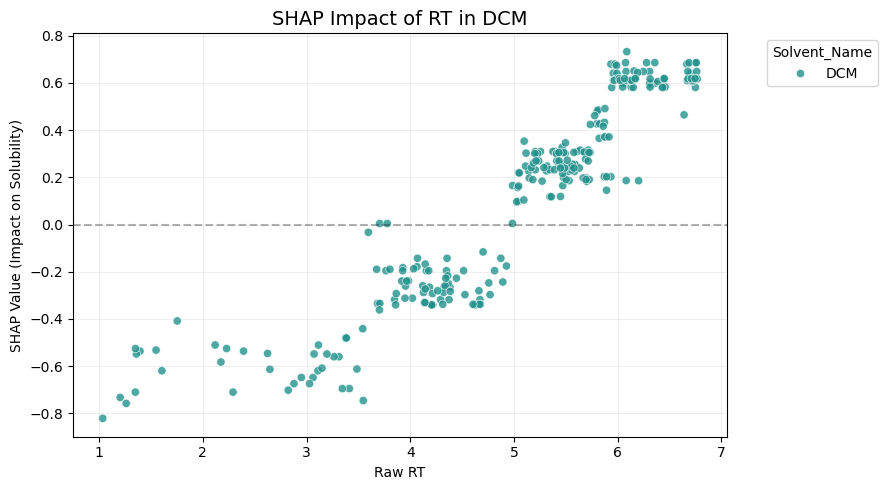

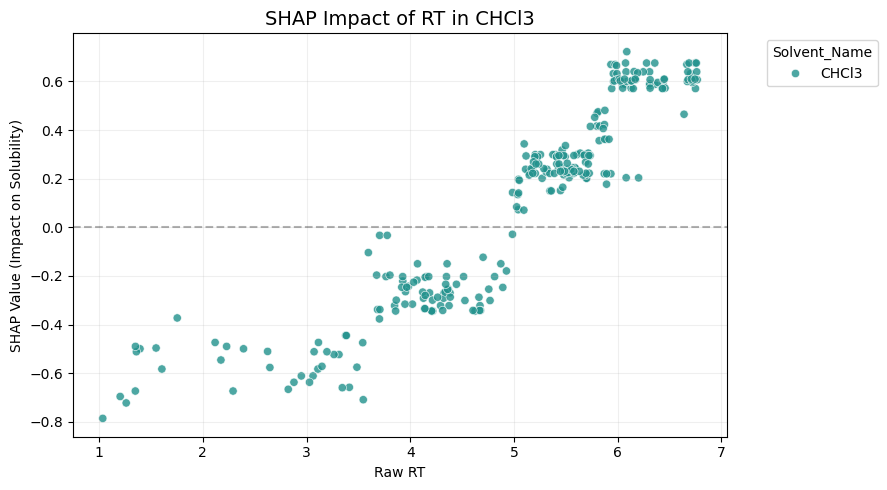

In [43]:
plot_catboost_solvent_gallery(
    model=model_cb, 
    X_test_df=X_test_cb, 
    base_feature='RT',       # You can change this to 'RT' or 'Matrix_Vector_1' later!
    color_col='Solvent_Name' 
)

In [52]:
print(df_desc)

                                                 SMILES     RT Matrix ID Name  \
0                                     CC(C1=CC=CC=C1)Br  5.607     BlueBird 1   
1                               C1C(CC(=O)NC1=O)CC(=O)O  1.146     BlueBird 1   
2                   C1=CC=C(C=C1)COC(=O)NCC(=O)NCC(=O)O  4.021     BlueBird 1   
3     C1=CC=C2C(=C1)C(C3=CC=CC=C32)COC(=O)N[C@@H](CC...  3.327     BlueBird 1   
4       C1C[C@H](P(=O)([C@@H]1C2=CC=CC=C2)O)C3=CC=CC=C3  5.678     BlueBird 1   
...                                                 ...    ...            ...   
4470  C1=CC=C(C=C1)COC(=O)[C@@H](CCC(=O)O)NC(=O)OCC2...  3.553       Sphinx 2   
4471      C1=CC=C(C=C1)COC(=O)N[C@H](C2=CC=CC=C2)C(=O)O  3.297       Sphinx 2   
4472                      C(C1=C(C(=C(C(=C1F)F)F)F)F)Br  6.066       Sphinx 2   
4473    C1=CC=C(C=C1)S(=O)(=O)/C=C/S(=O)(=O)C2=CC=CC=C2  5.567       Sphinx 2   
4474  C1CC(CCC1CNC(=O)OCC2C3=CC=CC=C3C4=CC=CC=C24)C(...  3.542       Sphinx 2   

          logS Solvent_Name